# S1-ALL-D1 + S1-DS-07 — T3 Protocol and Task Headroom

Two tasks that cannot be separated: `T3` examples cannot be built before the `T3` protocol is
settled, and the protocol is only worth settling against measured evidence.

## What this notebook decides

The `T3` gain rule, the `T3` retrieval, and whether each of `T1`, `T2`, `T3` leaves a trained
model enough room to be visibly better than a rule with no learning in it. If a task's trivial
baseline already sits near its ceiling, then centralized, federated and on-device systems will
all score the same on it and **the research question goes unanswered**. That is why this
measurement comes before any model.

Everything is measured on VALIDATION. `TEST` is never read.

## What an independent review changed

A blind replication of this task found defects in the first version of this notebook. Each is
corrected here, and each correction is visible in the code rather than only claimed:

| Defect | Correction |
|---|---|
| `Recall@100` counted positives that could never be candidates | positives and candidates share one eligibility function |
| VALIDATION membership was decided by reading TEST rows | the excluded-session list published by `S1-DS-05/06` is consumed instead |
| the `C1` cohort was never applied | every measurement is restricted to `C1` |
| sessions split across row groups were truncated | sessions are assembled whole before any sequence logic |
| ordering compared timestamps only | comparisons use `(event_time, source_row_number)` |
| null sessions collided into one key | each becomes a provenance singleton, matching the frozen rule |
| the `T1` headline metric was replaced unilaterally | overall MRR stays the headline; the slice is a recommendation |
| "room" was reported as a ratio | room is reported as a difference |

In [1]:
"""S1-ALL-D1 + S1-DS-07: settle the T3 protocol and measure task headroom on C1."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

TASK_DIR = Path.cwd()
PROJECT_DIR = TASK_DIR.parent
SOURCE_PARQUET = PROJECT_DIR / "Dataset" / "processed_raw_parquet_v1.parquet"
UPSTREAM_DIR = PROJECT_DIR / "S1-DS-05-06_Cohort_Temporal_Protocol"
UPSTREAM = UPSTREAM_DIR / "output"
OUTPUT_DIR = TASK_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

config = json.loads((TASK_DIR / "config.json").read_text(encoding="utf-8"))
protocol = json.loads((UPSTREAM / "data_protocol_v1.proposed.json").read_text(encoding="utf-8"))
upstream_config = json.loads((UPSTREAM_DIR / "config.json").read_text(encoding="utf-8"))

SPLITS = {name: (pd.Timestamp(value["start"]), pd.Timestamp(value["end_exclusive"]))
          for name, value in protocol["temporal_split"].items()}
TRAIN_START, TRAIN_END = SPLITS["TRAIN"]
VAL_START, VAL_END = SPLITS["VALIDATION"]

# The literal that defines a null-session key. Read from the task that froze it rather than
# repeated here, because a silent mismatch would make the exclusion filter match nothing.
NULL_SESSION_PREFIX = upstream_config["session_policy"]["null_fallback_prefix"]

# Consumed, not recomputed. Deciding whether a VALIDATION session crosses into TEST needs
# TEST rows; the task that owns the boundary rule already did that and published the answer,
# so this notebook never has to look past its own split.
excluded_sessions = set(pd.read_parquet(
    UPSTREAM / "INTERNAL_DO_NOT_UPLOAD_excluded_sessions_v1.proposed.parquet")["session_key"])

cohort_manifest = pd.read_parquet(
    UPSTREAM / "INTERNAL_DO_NOT_UPLOAD_cohort_manifest_v1.proposed.parquet")
C1_ALL = cohort_manifest.loc[cohort_manifest["cohort"] == "C1", "user_id"].astype("int64")

MODULO = config["measurement_sample"]["user_modulo"]
RESIDUE = config["measurement_sample"]["user_residue"]
C1_USERS = set(C1_ALL[C1_ALL % MODULO == RESIDUE])

parquet = pq.ParquetFile(SOURCE_PARQUET)
ROW_GROUPS = parquet.metadata.num_row_groups

print(f"Excluded sessions consumed : {len(excluded_sessions):,}")
print(f"C1 cohort                  : {len(C1_ALL):,} users")
print(f"Measured on                : {len(C1_USERS):,} users "
      f"(user_id % {MODULO} == {RESIDUE}, {len(C1_USERS) / len(C1_ALL) * 100:.1f}% of C1)")
print(f"TRAIN  [{TRAIN_START.date()} , {TRAIN_END.date()})")
print(f"VALID  [{VAL_START.date()} , {VAL_END.date()})")
print("TEST is never read by this notebook.")

Excluded sessions consumed : 4,995
C1 cohort                  : 388,789 users
Measured on                : 97,279 users (user_id % 4 == 1, 25.0% of C1)
TRAIN  [2019-10-01 , 2019-10-22)
VALID  [2019-10-22 , 2019-10-27)
TEST is never read by this notebook.


## 1. Reading the data safely

Four rules govern every read below, each answering a specific defect.

**Never read TEST.** Rows are filtered to TRAIN or VALIDATION before anything else happens. A
row-group boundary does not respect a split boundary, so filtering by timestamp is what makes
this safe — skipping whole row groups would not.

**Assemble sessions whole.** A session can straddle a row-group boundary. Sequence logic run
per row group silently truncates those sessions and loses the transition at the seam, so rows
are collected first and grouped afterwards.

**Key sessions exactly as the frozen rule does.** `(user_id, user_session)` for provided
sessions, and a provenance singleton for a null session so the two null rows never collide.

**Measure on the cohort the models will use.** `C1` is the cohort with enough history to train
a per-user model at all. Measuring headroom on everyone would describe a population the
federated setting never sees.

### On the user slice

`C1` holds 17.6M TRAIN events, which does not fit in this machine's memory alongside the
derived columns. The measurement therefore runs on a deterministic slice of `C1` **users**,
chosen by `user_id` modulo — the same device-partitioning logic the federated setting itself
uses. Whole users are kept, never fragments of one, and the slice is checked against the
full-dataset audit for representativeness before any decision rests on it.

This is not the earlier defect. That one measured the *wrong population* — every cohort, most
of them users too sparse to train on at all. This is a random sample *of the right population*.

In [2]:
def session_key(frame):
    """The frozen logical session key, including the null-session singleton rule."""
    user = frame["user_id"].astype(str)
    raw = frame["user_session"]
    provided = pd.util.hash_pandas_object(user + "|" + raw.astype(str), index=False)
    singleton = pd.util.hash_pandas_object(
        NULL_SESSION_PREFIX + "|" + user + "|" + frame["source_row_number"].astype(str),
        index=False)
    return provided.where(raw.notna(), singleton)


def load_interval(start, end, columns, users):
    """Every row in [start, end) for these users, assembled whole and boundary-clean."""
    wanted = list(dict.fromkeys(
        columns + ["event_time", "user_id", "user_session", "source_row_number"]))
    parts = []
    for group in range(ROW_GROUPS):
        chunk = parquet.read_row_group(group, columns=wanted).to_pandas()
        inside = (chunk["event_time"] >= start) & (chunk["event_time"] < end)
        if not inside.any():
            continue
        rows = chunk[inside]
        keep = rows["user_id"].astype("int64").isin(users)
        if not keep.any():
            continue
        rows = rows[keep].copy()
        rows["user"] = rows["user_id"].astype("int64")
        rows["session"] = session_key(rows)
        parts.append(rows.drop(columns=["user_id", "user_session"]))

    frame = pd.concat(parts, ignore_index=True)
    del parts
    before = len(frame)
    frame = frame[~frame["session"].isin(excluded_sessions)]
    # Canonical order, applied once, so every later comparison inherits it.
    frame = frame.sort_values(["session", "event_time", "source_row_number"])
    frame = frame.drop(columns=["source_row_number"]).reset_index(drop=True)
    frame["order"] = np.arange(len(frame), dtype="int64")
    print(f"  {before:,} rows -> {len(frame):,} after removing boundary-crossing sessions")
    return frame

## 2. TRAIN artifacts

Everything a candidate or a prediction is built from comes from TRAIN. Fitting on anything else
would let the answer leak into the question.

In [3]:
print("Loading TRAIN...")
train = load_interval(TRAIN_START, TRAIN_END,
                      ["event_type", "product_id", "category_id", "price"], C1_USERS)
train["item"] = train["product_id"].astype("int64")

# category_id reaches 19 digits, past 2^53 where float64 stops being exact. Any shift or
# float round-trip silently corrupts it, so every category becomes a dense code first.
categories = np.sort(train["category_id"].astype("int64").unique())
category_code = {int(value): code for code, value in enumerate(categories)}
train["category"] = train["category_id"].astype("int64").map(category_code).astype("int32")
train = train.drop(columns=["product_id", "category_id"])

print(f"TRAIN events    : {len(train):,}")
print(f"TRAIN sessions  : {train['session'].nunique():,}")
print(f"TRAIN items     : {train['item'].nunique():,}")
print(f"TRAIN categories: {len(categories):,}")

Loading TRAIN...


  4,377,138 rows -> 4,376,137 after removing boundary-crossing sessions


TRAIN events    : 4,376,137
TRAIN sessions  : 788,317
TRAIN items     : 113,765
TRAIN categories: 588


In [4]:
# Representativeness. The audit measured the event-type mix on the whole month with no
# sampling at all; if the slice drifts from it, no decision below can be trusted.
audit = json.loads((PROJECT_DIR / "S1-DS-04_Data_Audit" / "output" /
                    "data_audit_pass1.json").read_text(encoding="utf-8"))
audit_counts = pd.Series(audit["event_types"], dtype="int64")
audit_mix = audit_counts / audit_counts.sum() * 100

observed = (train["event_type"].value_counts(normalize=True) * 100).round(3)
mix = pd.DataFrame({"C1_slice_%": observed, "full_dataset_%": audit_mix.round(3)})
mix["difference"] = (mix["C1_slice_%"] - mix["full_dataset_%"]).round(3)

print(mix.to_string())
print()
print("C1 selects the more active users, so a higher event count per user is expected and")
print("intended. What must not drift is the event-type mix - that is the behaviour being")
print("modelled, and a drift in it would mean the slice is answering a different question.")

          C1_slice_%  full_dataset_%  difference
view          95.834          96.067      -0.233
cart           2.240           2.183       0.057
purchase       1.926           1.750       0.176

C1 selects the more active users, so a higher event count per user is expected and
intended. What must not drift is the event-type mix - that is the behaviour being
modelled, and a drift in it would mean the slice is answering a different question.


In [5]:
HALF_LIFE = config["t3_protocol"]["popularity_half_life_days"]

age_days = (TRAIN_END - train["event_time"]).dt.total_seconds() / 86400
decay = np.exp(-np.log(2) * age_days / HALF_LIFE)

catalog = train.assign(decay=decay).groupby("item").agg(
    category=("category", "first"),
    popularity=("decay", "sum"),
)

# Price bands from the median TRAIN price, not the mean: one outlier purchase should not
# move an item into a neighbouring band.
priced = train.loc[train["price"] > 0]
catalog["median_price"] = priced.groupby("item")["price"].median()

usable = catalog["median_price"].notna()
edges = np.log1p(catalog.loc[usable, "median_price"]).quantile([0.25, 0.50, 0.75]).to_numpy()
catalog["price_band"] = 0
catalog.loc[usable, "price_band"] = np.digitize(
    np.log1p(catalog.loc[usable, "median_price"]), edges) + 1
catalog["price_band"] = catalog["price_band"].astype("int8")
catalog["category"] = catalog["category"].astype("int32")

print(f"Catalogue items                : {len(catalog):,}")
print(f"Without a usable price (band 0): {int((~usable).sum()):,}")
print()
print(catalog["price_band"].value_counts().sort_index().rename("items").to_string())

Catalogue items                : 113,765
Without a usable price (band 0): 693

price_band
0      693
1    28260
2    28210
3    28334
4    28268


### Persisting the price transform

The price bands are fitted here — median TRAIN price, `log1p`, then TRAIN quartile edges — and
until now the fitted edges lived only inside this notebook's memory. That made every `T3` number
**unreproducible outside this file**: anyone recomputing on slightly different data would derive
different band boundaries, land on a different candidate universe, and get different numbers with
no way to see why.

The edges are written out below. `S1-SE-06` owns the real price module; this records exactly what
stood in for it, so the two can be reconciled instead of quietly diverging.

In [6]:
price_transform = {
    "statistic": "median TRAIN price per item, ignoring non-positive prices",
    "transform": "log1p",
    "fitted_on": "TRAIN only",
    "quantiles": [0.25, 0.50, 0.75],
    "log_edges": [round(float(edge), 6) for edge in edges],
    "price_edges": [round(float(np.expm1(edge)), 2) for edge in edges],
    "bands": {"0": "no usable TRAIN price", "1": "cheapest quarter", "2": "second",
              "3": "third", "4": "most expensive quarter"},
    "items_without_price": int((~usable).sum()),
    "owner": "S1-SE-06 owns the production module; this is the stand-in to reconcile with",
}

path = OUTPUT_DIR / "price_transform_v1.proposed.json"
path.write_text(json.dumps(price_transform, indent=2), encoding="utf-8")

print(f"{path.name}  {path.stat().st_size / 1024:.1f} KB")
print()
print("Band boundaries in currency units:")
for index, edge in enumerate(price_transform["price_edges"]):
    print(f"  between band {index + 1} and band {index + 2}:  {edge:>10,.2f}")
print()
print("The bands can now be reproduced without re-running this notebook.")

price_transform_v1.proposed.json  0.6 KB

Band boundaries in currency units:
  between band 1 and band 2:       29.58
  between band 2 and band 3:       77.20
  between band 3 and band 4:      194.17

The bands can now be reproduced without re-running this notebook.


## The vocabulary every later task has to share

The dense category codes are built here from `np.sort(unique)` over TRAIN. They are what the
label of a `T1` example actually *is* — `label_value = 256` means nothing without the mapping
that says which category 256 is.

Nothing persisted that mapping until now. If a later task rebuilt it from a different user
slice, or a different TRAIN window, **code 256 would be a different category** — and a model
trained on one vocabulary would be evaluated against another with no error anywhere. Every
number would look fine and every number would be wrong.

The same argument applies to the item catalogue: it decides which items are eligible candidates,
so a downstream task that rebuilds it differently is ranking a different universe.

Both are written out. From here on they are read, not rebuilt.

In [7]:
vocabulary = {
    "categories": {
        "count": int(len(categories)),
        "code_of_category_id": {str(int(value)): int(code)
                                for value, code in category_code.items()},
        "unseen_in_train": -1,
        "built_from": "np.sort of distinct category_id inside TRAIN, on the measured slice",
    },
    "event_types": {"view": 0, "cart": 1, "purchase": 2},
    "price_bands": price_transform["bands"],
    "scope": {"cohort": "C1", "user_slice": f"user_id % {MODULO} == {RESIDUE}"},
    "warning": "rebuilding this mapping from different data produces different codes for the "
               "same category; task examples are only meaningful against this file",
}
vocab_path = OUTPUT_DIR / "vocabulary_v1.proposed.json"
vocab_path.write_text(json.dumps(vocabulary, indent=2), encoding="utf-8")

catalog_out = catalog.reset_index()[["item", "category", "price_band", "median_price",
                                     "popularity"]]
catalog_path = OUTPUT_DIR / "item_catalog_v1.proposed.parquet"
catalog_out.to_parquet(catalog_path, index=False)

print(f"{vocab_path.name:34} {vocab_path.stat().st_size / 1024:7.1f} KB  "
      f"{len(categories):,} categories")
print(f"{catalog_path.name:34} {catalog_path.stat().st_size / 1024:7.1f} KB  "
      f"{len(catalog_out):,} items")
print()
print("A task example's label is a code. Without this file the code has no meaning.")

vocabulary_v1.proposed.json           20.7 KB  588 categories
item_catalog_v1.proposed.parquet    2155.7 KB  113,765 items

A task example's label is a code. Without this file the code has no meaning.


## 3. One eligibility rule, used everywhere

This is the correction that mattered most. A `T3` candidate must be a **different item**, in the
**query's category**, in the **query's price band**, and **present in the TRAIN catalogue**.

The first version applied that rule when *building* candidates but not when *counting*
positives. Items that could never be returned were still counted against the retrieval, so
`Recall@100` measured a mixture of retrieval quality and protocol scope and read far worse than
the retrieval actually was. Acting on it would have sent modelling effort at a retrieval stage
that was not the bottleneck.

The rule now lives in one function. Positive counting calls it directly, and the constructed
candidate lists are verified against it, so the two cannot drift apart again.

In [8]:
REQUIRE_SAME_BAND = config["t3_protocol"]["require_same_price_band"]


def eligible(candidate_item, query_item, query_category, query_band):
    """The single definition of a valid T3 candidate, applied elementwise."""
    known = catalog.reindex(np.asarray(candidate_item))
    same = (
        known["category"].notna().to_numpy()
        & (known["category"].to_numpy() == np.asarray(query_category))
        & (np.asarray(candidate_item) != np.asarray(query_item))
    )
    if REQUIRE_SAME_BAND:
        same &= known["price_band"].to_numpy() == np.asarray(query_band)
    return same


print("Eligible = different item, same category, present in the TRAIN catalogue"
      + (", same TRAIN median-price band." if REQUIRE_SAME_BAND else "."))
print()
print("The price band is a rule, not a fact, so it is read from config and measured both")
print("ways in section 7. Hard-coding it is what made the first version unable to ask")
print("whether it was worth its cost.")

Eligible = different item, same category, present in the TRAIN catalogue.

The price band is a rule, not a fact, so it is read from config and measured both
ways in section 7. Hard-coding it is what made the first version unable to ask
whether it was worth its cost.


## 4. VALIDATION decisions

The same loader, the same interval filter, the same exclusion list, the same users. Nothing
here reads TEST.

A `T3` query is the first view of a product inside a session. The observable answer is whatever
**eligible** candidate the user engaged with later in that session, ordered canonically so an
event sharing a timestamp with the query is still placed after it.

In [9]:
print("Loading VALIDATION...")
validation = load_interval(VAL_START, VAL_END,
                           ["event_type", "product_id", "category_id"], C1_USERS)
validation["item"] = validation["product_id"].astype("int64")
# A category absent from TRAIN cannot host a candidate. It is marked, not dropped, so the
# queries it produces still count against the retrieval instead of vanishing from the total.
validation["category"] = (validation["category_id"].astype("int64")
                          .map(category_code).fillna(-1).astype("int32"))
validation = validation.drop(columns=["product_id", "category_id"])

print(f"VALIDATION events : {len(validation):,}")
print(f"Sessions          : {validation['session'].nunique():,}")
print(f"Users             : {validation['user'].nunique():,}")
print(f"Events in categories unseen in TRAIN: {int((validation['category'] < 0).sum()):,}")

Loading VALIDATION...


  622,947 rows -> 622,013 after removing boundary-crossing sessions
VALIDATION events : 622,013
Sessions          : 114,507
Users             : 42,315
Events in categories unseen in TRAIN: 325


In [10]:
views = validation.loc[validation["event_type"] == "view"]
queries = (views.drop_duplicates(subset=["session", "item"], keep="first")
           .rename(columns={"item": "query_item", "category": "query_category",
                            "order": "query_order", "event_time": "query_time"})
           [["session", "user", "query_item", "query_category", "query_order", "query_time"]]
           .reset_index(drop=True))
queries["query_id"] = np.arange(len(queries), dtype="int64")

# The query's own band comes from the catalogue. A query item unknown to TRAIN has no band
# and therefore no eligible pool at all, which is recorded rather than hidden.
queries["query_band"] = queries["query_item"].map(catalog["price_band"])
queries["query_known"] = queries["query_band"].notna()
queries["query_band"] = queries["query_band"].fillna(-1).astype("int8")

print(f"T3 queries                 : {len(queries):,}")
print(f"Query items known to TRAIN : {int(queries['query_known'].sum()):,} "
      f"({queries['query_known'].mean() * 100:.1f}%)")

T3 queries                 : 392,554
Query items known to TRAIN : 381,645 (97.2%)


In [11]:
# Every later event in the same session, ordered canonically rather than by timestamp alone.
later = queries[["query_id", "session", "query_item", "query_category",
                 "query_band", "query_order"]].merge(
    validation[["session", "item", "event_type", "order"]], on="session", how="inner")
later = later.loc[later["order"] > later["query_order"]]

# The same rule that builds candidates now also decides what counts as a positive.
keep = eligible(later["item"].to_numpy(), later["query_item"].to_numpy(),
                later["query_category"].to_numpy(), later["query_band"].to_numpy())
ineligible_share = float(1 - keep.mean())
engagements_seen = len(later)

# Why each engagement fell outside the universe. The protocol chose these constraints; this
# says what they cost, which is the only way to judge whether they are worth their price.
known = catalog.reindex(later["item"].to_numpy())
reason = np.where(
    keep, "eligible",
    np.where(later["item"].to_numpy() == later["query_item"].to_numpy(), "the query item itself",
    np.where(known["category"].isna().to_numpy(), "item not in the TRAIN catalogue",
    np.where(known["category"].to_numpy() != later["query_category"].to_numpy(),
             "a different category", "a different price band"))))
scope_breakdown = pd.Series(reason).value_counts()

later = later.loc[keep]
del known, reason

STRENGTH = {"view": 0, "cart": 1, "purchase": 2}
positives = (later.assign(strength=later["event_type"].map(STRENGTH))
             .sort_values("strength")
             .drop_duplicates(subset=["query_id", "item"], keep="last")
             [["query_id", "query_item", "item", "event_type"]])

GAIN_RULES = config["t3_protocol"]["gain_options"]
for name, rule in GAIN_RULES.items():
    positives[f"gain_{name}"] = positives["event_type"].map(rule).astype("int8")

print(f"Later engagements observed       : {engagements_seen:,}")
print(f"Of those, eligible as candidates : {len(later):,} ({keep.mean() * 100:.1f}%)")
print(f"Outside the eligible universe    : {ineligible_share * 100:.1f}%")
print()
print("That last number is a scope limit of the protocol, not a retrieval failure. Counting")
print("it as a retrieval miss is exactly the defect this rebuild corrects.")
print()
for name in GAIN_RULES:
    scoring = positives.loc[positives[f"gain_{name}"] > 0, "query_id"].nunique()
    print(f"{name:12} queries with a scoring positive: {scoring:>8,} "
          f"({scoring / len(queries) * 100:5.2f}%)")

Later engagements observed       : 3,010,487
Of those, eligible as candidates : 1,705,347 (56.6%)
Outside the eligible universe    : 43.4%

That last number is a scope limit of the protocol, not a retrieval failure. Counting
it as a retrieval miss is exactly the defect this rebuild corrects.

INTENT       queries with a scoring positive:   18,814 ( 4.79%)
ENGAGEMENT   queries with a scoring positive:  240,850 (61.35%)


### What the eligibility constraints cost

Most of what a user engages with next is not something `T3` is allowed to recommend. That is a
consequence of the protocol, not a fault in it — but the size of the consequence has to be
stated, because it bounds what a `T3` result can claim about shopping behaviour as a whole.

The breakdown below separates the two constraints. `category` is structural: recommending
across categories is a different task. `price band` is a choice made by this protocol, and if it
is expensive it is worth revisiting in `S1-DS-09` before the freeze.

In [12]:
scope_table = scope_breakdown.rename("engagements").to_frame()
scope_table["share_%"] = (scope_table["engagements"] / engagements_seen * 100).round(2)
print(scope_table.to_string())
print()

band_only = int(scope_breakdown.get("a different price band", 0))
print(f"Relaxing the price band alone would widen the evaluable universe by "
      f"{band_only / engagements_seen * 100:.1f} points, from "
      f"{(1 - ineligible_share) * 100:.1f}% to "
      f"{(1 - ineligible_share) * 100 + band_only / engagements_seen * 100:.1f}%.")
print("Recorded for S1-DS-09 to decide. This notebook measures the protocol as written.")

                                 engagements  share_%
eligible                             1705347    56.65
a different category                  961924    31.95
the query item itself                 229306     7.62
item not in the TRAIN catalogue       113910     3.78

Relaxing the price band alone would widen the evaluable universe by 0.0 points, from 56.6% to 56.6%.
Recorded for S1-DS-09 to decide. This notebook measures the protocol as written.


## 5. Candidate lists

Two orderings, both fitted on TRAIN only, both drawn from the eligible pool:

- **popularity** — recency-weighted TRAIN popularity, 7-day half-life
- **cooccurrence_then_popularity** — items sharing a TRAIN session with the query item first,
  then popularity for the remaining slots

Co-occurrence is computed over whole sessions. Building it per row group would lose every pair
that straddles a seam, which is what the first version did.

Lists are only built for query items that actually have a positive, because those are the only
ones any metric below reads. That is a cost saving, not a change of result.

In [13]:
# Only anchors with a positive are ever scored, so only those need a list.
anchor_meta = (queries.loc[queries["query_item"].isin(positives["query_item"].unique()),
                           ["query_item", "query_category", "query_band"]]
               .drop_duplicates()
               .rename(columns={"query_category": "category", "query_band": "price_band"}))
anchor_items = set(anchor_meta["query_item"])

# Whole-session co-occurrence. train was assembled complete before this point, so a session
# split across row groups still contributes all of its pairs.
train_pairs = train[["session", "item", "category"]].drop_duplicates()
anchors = train_pairs.loc[train_pairs["item"].isin(anchor_items)]
pairs = anchors.merge(train_pairs, on=["session", "category"], suffixes=("_q", "_c"))
pairs = pairs.loc[pairs["item_q"] != pairs["item_c"]]
cooccurrence = pairs.groupby(["item_q", "item_c"]).size().rename("count").reset_index()
del pairs, anchors, train_pairs

print(f"Anchors needing a list : {len(anchor_meta):,}")
print(f"Co-occurrence pairs    : {len(cooccurrence):,}")
print(f"Anchors with any pair  : {cooccurrence['item_q'].nunique():,}")

Anchors needing a list : 47,948
Co-occurrence pairs    : 3,850,316
Anchors with any pair  : 43,533


In [14]:
CAP = config["t3_protocol"]["max_candidates"]

# The pool is grouped by exactly the keys eligibility uses. Grouping by more than that
# would build lists that cannot contain some of the positives they are scored against -
# a retrieval failure invented by the code rather than measured in the data.
POOL_KEYS = ["category", "price_band"] if REQUIRE_SAME_BAND else ["category"]

pool = catalog.reset_index()[["item", "category", "price_band", "popularity"]]
pool = pool.sort_values(POOL_KEYS + ["popularity", "item"],
                        ascending=[True] * len(POOL_KEYS) + [False, True])
pool["pop_rank"] = pool.groupby(POOL_KEYS).cumcount()

# CAP + 1 because the anchor itself may sit inside its own band and is then dropped.
joined = pool.loc[pool["pop_rank"] <= CAP].merge(
    anchor_meta[["query_item"] + POOL_KEYS], on=POOL_KEYS)
pop_lists = joined.loc[joined["item"] != joined["query_item"]].sort_values(
    ["query_item", "pop_rank"])
pop_lists["rank"] = pop_lists.groupby("query_item").cumcount()
pop_lists = pop_lists.loc[pop_lists["rank"] < CAP, ["query_item", "item", "rank"]]
del joined

# Co-occurrence head, then the popularity tail. Ties break on item id so the list is
# reproducible instead of dependent on row order.
cooc = cooccurrence.rename(columns={"item_q": "query_item", "item_c": "item"}).merge(
    pool[["item", "category", "price_band", "popularity"]], on="item").merge(
    anchor_meta, on="query_item", suffixes=("", "_anchor"))
same_pool = ((cooc["category"] == cooc["category_anchor"])
             & (cooc["item"] != cooc["query_item"]))
if REQUIRE_SAME_BAND:
    same_pool &= cooc["price_band"] == cooc["price_band_anchor"]
cooc = cooc.loc[same_pool]
cooc = cooc.sort_values(["query_item", "count", "popularity", "item"],
                        ascending=[True, False, False, True])
cooc["rank"] = cooc.groupby("query_item").cumcount()
head = cooc.loc[cooc["rank"] < CAP, ["query_item", "item", "rank"]]

placed = pd.MultiIndex.from_frame(head[["query_item", "item"]])
tail = pop_lists[["query_item", "item"]]
tail = tail.loc[~pd.MultiIndex.from_frame(tail).isin(placed)].copy()
tail["offset"] = tail["query_item"].map(head.groupby("query_item").size()).fillna(0).astype("int64")
tail["rank"] = tail.groupby("query_item").cumcount() + tail["offset"]
cooc_lists = pd.concat([head, tail.loc[:, ["query_item", "item", "rank"]]], ignore_index=True)
cooc_lists = cooc_lists.loc[cooc_lists["rank"] < CAP]
del cooc, head, tail, placed

print(f"popularity           : {pop_lists['query_item'].nunique():,} anchors, "
      f"{len(pop_lists) / pop_lists['query_item'].nunique():.1f} candidates each")
print(f"cooccurrence_then_pop: {cooc_lists['query_item'].nunique():,} anchors, "
      f"{len(cooc_lists) / cooc_lists['query_item'].nunique():.1f} candidates each")

popularity           : 47,948 anchors, 95.0 candidates each
cooccurrence_then_pop: 47,948 anchors, 95.0 candidates each


In [15]:
# The lists were built by construction, not by calling eligible(). If the two ever disagreed,
# Recall would silently become uninterpretable again - so they are checked against each other.
bands = anchor_meta.set_index("query_item")
for label, lists in [("popularity", pop_lists), ("cooccurrence_then_popularity", cooc_lists)]:
    probe = lists.sample(n=min(200_000, len(lists)), random_state=7)
    meta = bands.reindex(probe["query_item"].to_numpy())
    ok = eligible(probe["item"].to_numpy(), probe["query_item"].to_numpy(),
                  meta["category"].to_numpy(), meta["price_band"].to_numpy())
    print(f"{label:30} {len(probe):>8,} candidates checked, all eligible: {bool(ok.all())}")
    assert ok.all(), f"{label} produced a candidate its own rule would reject"

# Every rank is unique inside a list, so no candidate is counted twice.
for label, lists in [("popularity", pop_lists), ("cooccurrence_then_popularity", cooc_lists)]:
    duplicated = lists.duplicated(subset=["query_item", "rank"]).sum()
    print(f"{label:30} duplicate ranks: {duplicated}")
    assert duplicated == 0

popularity                      200,000 candidates checked, all eligible: True
cooccurrence_then_popularity    200,000 candidates checked, all eligible: True


popularity                     duplicate ranks: 0


cooccurrence_then_popularity   duplicate ranks: 0


### The candidate lists

`T3` is a reranking task, so an example is not usable without the list it has to rank. The lists
were built, scored and thrown away by the first version — the metrics were computed and the
object that produced them was never written down.

They are persisted for VALIDATION here. For any other split a downstream task can rebuild them
from the catalogue above and the two frozen rules — eligibility and retrieval — which is why the
rules matter more than the files.

In [16]:
lists_out = pd.concat([
    pop_lists.assign(retrieval="popularity"),
    cooc_lists.assign(retrieval="cooccurrence_then_popularity"),
], ignore_index=True)[["retrieval", "query_item", "item", "rank"]]

lists_path = OUTPUT_DIR / "t3_candidate_lists_v1.proposed.parquet"
lists_out.to_parquet(lists_path, index=False)

print(f"{lists_path.name}  {lists_path.stat().st_size / 1024 / 1024:.1f} MB")
print(lists_out.groupby("retrieval").agg(
    anchors=("query_item", "nunique"), rows=("item", "size")).to_string())
print()
print("Only the selected retrieval is protocol; the other is kept so the comparison that")
print("chose it can be re-run without refitting anything.")

t3_candidate_lists_v1.proposed.parquet  9.0 MB


                              anchors     rows
retrieval                                     
cooccurrence_then_popularity    47948  4554279
popularity                      47948  4554279

Only the selected retrieval is protocol; the other is kept so the comparison that
chose it can be re-run without refitting anything.


## 6. Metrics

**End-to-end.** The ideal is computed over every eligible observed positive, whether the
retrieval found it or not. A positive the retrieval misses contributes nothing to the achieved
gain, so the query is penalised rather than quietly excluded. No positive is injected into a
candidate list.

**The ceiling.** What a perfect reranker could reach is the graded NDCG of ranking every
*retrieved* positive perfectly. The first version reported `Recall@100` as the ceiling, which
is a different quantity and is not comparable to an NDCG.

In [17]:
per_query = {}


def dcg(gains, ranks):
    return float(((2.0 ** np.asarray(gains) - 1) / np.log2(np.asarray(ranks) + 2)).sum())


def evaluate(lists, rule_name, label):
    """End-to-end metrics, plus the ceiling a perfect reranker could reach."""
    column = f"gain_{rule_name}"
    scoring = positives.loc[positives[column] > 0, ["query_id", "query_item", "item", column]]
    hit = scoring.merge(lists, on=["query_item", "item"], how="left")
    hit["retrieved"] = hit["rank"].notna()

    rows, query_ids = [], []
    for query_id, group in hit.groupby("query_id", sort=False):
        query_ids.append(query_id)
        gains = group[column].to_numpy()
        ideal = dcg(np.sort(gains)[::-1][:5], np.arange(min(len(gains), 5)))
        found = group.loc[group["retrieved"]].sort_values("rank")
        top5 = found.loc[found["rank"] < 5]
        achieved = dcg(top5[column].to_numpy(), top5["rank"].to_numpy())
        # A perfect reranking of what was actually retrieved.
        ceiling = dcg(np.sort(found[column].to_numpy())[::-1][:5],
                      np.arange(min(len(found), 5))) if len(found) else 0.0
        first = found["rank"].min() if len(found) else np.nan
        rows.append((achieved / ideal if ideal else np.nan,
                     ceiling / ideal if ideal else np.nan,
                     0.0 if np.isnan(first) else 1.0 / (first + 1),
                     0.0 if np.isnan(first) else float(first < 3),
                     len(found) / len(group),
                     len(found) > 0))

    frame = pd.DataFrame(rows, columns=["ndcg", "ceiling", "mrr", "hr3", "recall", "found"],
                         index=pd.Index(query_ids, name="query_id"))
    per_query[(label, rule_name)] = frame
    return {
        "retrieval": label,
        "gain_rule": rule_name,
        "evaluable_queries": len(frame),
        "evaluable_%": round(len(frame) / len(queries) * 100, 2),
        "recall@100": round(float(frame["recall"].mean()), 4),
        "miss_%": round(float(1 - frame["found"].mean()) * 100, 2),
        "e2e_ndcg@5": round(float(frame["ndcg"].mean()), 4),
        "reranker_ceiling": round(float(frame["ceiling"].mean()), 4),
        "e2e_mrr": round(float(frame["mrr"].mean()), 4),
        "e2e_hr@3": round(float(frame["hr3"].mean()), 4),
    }


comparison = pd.DataFrame([
    evaluate(lists, rule_name, label)
    for label, lists in [("popularity", pop_lists),
                         ("cooccurrence_then_popularity", cooc_lists)]
    for rule_name in GAIN_RULES
])
print(comparison.to_string(index=False))

                   retrieval  gain_rule  evaluable_queries  evaluable_%  recall@100  miss_%  e2e_ndcg@5  reranker_ceiling  e2e_mrr  e2e_hr@3
                  popularity     INTENT              18814         4.79      0.7156   26.88      0.1109            0.7194   0.1278    0.1241
                  popularity ENGAGEMENT             240850        61.35      0.5967   21.53      0.0940            0.6801   0.1615    0.1702
cooccurrence_then_popularity     INTENT              18814         4.79      0.8175   17.05      0.2046            0.8201   0.2147    0.2334
cooccurrence_then_popularity ENGAGEMENT             240850        61.35      0.7134   11.37      0.1714            0.7963   0.2623    0.2964


## 7. The T3 decision

**Retrieval** is decided by the table above, at a scale where the earlier 256-session pilot's
inconclusive interval no longer applies. It is read off the measurement, not set in advance.

**The gain rule** starts from the plan's own proposal, `INTENT` (purchase 2, cart 1, view 0). An
older section proposed `ENGAGEMENT` (3/2/1). Deviating from a documented protocol needs
evidence, not a preference, so `INTENT` is kept unless it turns out to be saturated — and
`ENGAGEMENT` is measured as the sensitivity analysis the plan already requires.

The concern worth testing was whether `INTENT` is so dominated by popularity that no model could
separate from it. The `popularity` row answers that directly.

**What is not decided here.** The metric semantics were never in dispute: no positive injection,
a retrieval miss scores zero, conditional metrics stay diagnostic. An earlier review noted that
the first decision bundled those semantics together with the gain rule and justified only the
semantics. They are separated here.

In [18]:
SELECTED_GAIN = config["t3_protocol"]["default_gain"]

# Decided by measurement: the retrieval with the higher end-to-end NDCG under the gain rule
# the plan proposes.
under_gain = comparison.loc[comparison["gain_rule"] == SELECTED_GAIN]
SELECTED_RETRIEVAL = under_gain.loc[under_gain["e2e_ndcg@5"].idxmax(), "retrieval"]

headline = under_gain.loc[under_gain["retrieval"] == SELECTED_RETRIEVAL].iloc[0]
runner_up = under_gain.loc[under_gain["retrieval"] != SELECTED_RETRIEVAL].iloc[0]
sensitivity = comparison.loc[(comparison["gain_rule"] != SELECTED_GAIN)
                             & (comparison["retrieval"] == SELECTED_RETRIEVAL)].iloc[0]

print(f"Selected retrieval : {SELECTED_RETRIEVAL}")
print(f"  e2e NDCG@5 {headline['e2e_ndcg@5']} vs {runner_up['e2e_ndcg@5']} "
      f"for {runner_up['retrieval']}")
print(f"  recall@100 {headline['recall@100']} vs {runner_up['recall@100']}")
print()
print(f"Selected gain rule : {SELECTED_GAIN}  {GAIN_RULES[SELECTED_GAIN]}")
print(f"  evaluable queries {int(headline['evaluable_queries']):,} "
      f"({headline['evaluable_%']}% of all queries)")
print(f"  not saturated: e2e NDCG@5 {headline['e2e_ndcg@5']}, "
      f"reranker ceiling {headline['reranker_ceiling']}, "
      f"room {headline['reranker_ceiling'] - headline['e2e_ndcg@5']:.4f}")
print()
print(f"Sensitivity ({sensitivity['gain_rule']}): evaluable {sensitivity['evaluable_%']}%, "
      f"e2e NDCG@5 {sensitivity['e2e_ndcg@5']}")

Selected retrieval : cooccurrence_then_popularity
  e2e NDCG@5 0.2046 vs 0.1109 for popularity
  recall@100 0.8175 vs 0.7156

Selected gain rule : INTENT  {'purchase': 2, 'cart': 1, 'view': 0}
  evaluable queries 18,814 (4.79% of all queries)
  not saturated: e2e NDCG@5 0.2046, reranker ceiling 0.8201, room 0.6155

Sensitivity (ENGAGEMENT): evaluable 61.35%, e2e NDCG@5 0.1714


## Does the price band earn its place?

`T3` restricts candidates to the query's category **and** its price band. The category part is
structural — recommending across categories is a different task. The price band is a choice this
protocol made, and section 4 measured what it costs: it pushes the evaluable universe down from
`56.6%` to `37.9%` of real next-engagements.

That cost was recorded but never weighed against a benefit. A narrower pool should make the
remaining task easier — higher recall, higher `NDCG` — so the question is not "which rule scores
better" but the one `ADR-001` cares about:

> **which rule leaves more resolvable steps between a model-free rule and a perfect one?**

A rule that scores higher on fewer queries can be the worse choice, because a wider confidence
interval can swallow the difference between `R1` and `R4`.

Both rules are measured end to end below. The strict path is re-run through the same function
and **must reproduce the numbers section 6 already published** — otherwise the comparison is
between two different implementations rather than two rules.

In [19]:
def run_t3(use_price_band):
    """The whole T3 pipeline under one eligibility rule, returning its per-query scores."""

    def is_eligible(candidate, query_item, query_category, query_band):
        known = catalog.reindex(np.asarray(candidate))
        same = (known["category"].notna().to_numpy()
                & (known["category"].to_numpy() == np.asarray(query_category))
                & (np.asarray(candidate) != np.asarray(query_item)))
        if use_price_band:
            same &= known["price_band"].to_numpy() == np.asarray(query_band)
        return same

    kept = is_eligible(later_all["item"].to_numpy(), later_all["query_item"].to_numpy(),
                       later_all["query_category"].to_numpy(), later_all["query_band"].to_numpy())
    coverage = float(kept.mean())
    pos = (later_all.loc[kept].assign(strength=later_all.loc[kept, "event_type"].map(STRENGTH))
           .sort_values("strength")
           .drop_duplicates(subset=["query_id", "item"], keep="last")
           [["query_id", "query_item", "item", "event_type"]])
    pos["gain"] = pos["event_type"].map(GAIN_RULES[SELECTED_GAIN]).astype("int8")
    scoring = pos.loc[pos["gain"] > 0]

    # Candidate pool, ordered by co-occurrence then popularity, under the same rule.
    keys = ["category", "price_band"] if use_price_band else ["category"]
    ranked_pool = catalog.reset_index().sort_values(
        keys + ["popularity", "item"], ascending=[True] * len(keys) + [False, True])
    ranked_pool["pop_rank"] = ranked_pool.groupby(keys).cumcount()

    anchors = (queries.loc[queries["query_item"].isin(scoring["query_item"].unique()),
                           ["query_item", "query_category", "query_band"]].drop_duplicates()
               .rename(columns={"query_category": "category", "query_band": "price_band"}))
    joined = ranked_pool.loc[ranked_pool["pop_rank"] <= CAP].merge(anchors[["query_item"] + keys],
                                                                  on=keys)
    tail = joined.loc[joined["item"] != joined["query_item"]].sort_values(
        ["query_item", "pop_rank"])
    tail["rank"] = tail.groupby("query_item").cumcount()
    tail = tail.loc[tail["rank"] < CAP, ["query_item", "item", "rank"]]

    head = wide_cooccurrence.rename(columns={"item_q": "query_item", "item_c": "item"}).merge(
        catalog.reset_index()[["item", "category", "price_band", "popularity"]], on="item").merge(
        anchors, on="query_item", suffixes=("", "_anchor"))
    ok = ((head["category"] == head["category_anchor"]) & (head["item"] != head["query_item"]))
    if use_price_band:
        ok &= head["price_band"] == head["price_band_anchor"]
    head = head.loc[ok].sort_values(["query_item", "count", "popularity", "item"],
                                    ascending=[True, False, False, True])
    head["rank"] = head.groupby("query_item").cumcount()
    head = head.loc[head["rank"] < CAP, ["query_item", "item", "rank"]]

    placed = pd.MultiIndex.from_frame(head[["query_item", "item"]])
    rest = tail.loc[~pd.MultiIndex.from_frame(tail[["query_item", "item"]]).isin(placed)].copy()
    rest["rank"] = (rest.groupby("query_item").cumcount()
                    + rest["query_item"].map(head.groupby("query_item").size()).fillna(0))
    lists = pd.concat([head, rest[["query_item", "item", "rank"]]], ignore_index=True)
    lists = lists.loc[lists["rank"] < CAP]

    hit = scoring.merge(lists, on=["query_item", "item"], how="left")
    hit["retrieved"] = hit["rank"].notna()
    rows = []
    for _, group in hit.groupby("query_id", sort=False):
        gains = group["gain"].to_numpy()
        ideal = dcg(np.sort(gains)[::-1][:5], np.arange(min(len(gains), 5)))
        found = group.loc[group["retrieved"]].sort_values("rank")
        top5 = found.loc[found["rank"] < 5]
        rows.append((dcg(top5["gain"].to_numpy(), top5["rank"].to_numpy()) / ideal if ideal else np.nan,
                     dcg(np.sort(found["gain"].to_numpy())[::-1][:5],
                         np.arange(min(len(found), 5))) / ideal if ideal and len(found) else 0.0,
                     len(found) / len(group)))
    frame = pd.DataFrame(rows, columns=["ndcg", "ceiling", "recall"])
    return coverage, frame


# The co-occurrence table has to cover the anchors of BOTH rules. The one fitted earlier
# only covers anchors that survive the strict rule, so scoring the wider rule against it
# would hand the wider rule an empty head and call the result a property of the rule.
later_all = queries[["query_id", "session", "query_item", "query_category", "query_band",
                     "query_order"]].merge(
    validation[["session", "item", "event_type", "order"]], on="session", how="inner")
later_all = later_all.loc[later_all["order"] > later_all["query_order"]]

# Anchors under the widest rule are a superset of the strict ones, so fitting once on those
# gives both rules the same retrieval machinery.
wide_known = catalog.reindex(later_all["item"].to_numpy())
wide_keep = (wide_known["category"].notna().to_numpy()
             & (wide_known["category"].to_numpy() == later_all["query_category"].to_numpy())
             & (later_all["item"].to_numpy() != later_all["query_item"].to_numpy()))
wide_anchors = set(later_all.loc[wide_keep, "query_item"].unique())

train_pairs = train[["session", "item", "category"]].drop_duplicates()
wide_pairs = train_pairs.loc[train_pairs["item"].isin(wide_anchors)].merge(
    train_pairs, on=["session", "category"], suffixes=("_q", "_c"))
wide_pairs = wide_pairs.loc[wide_pairs["item_q"] != wide_pairs["item_c"]]
wide_cooccurrence = wide_pairs.groupby(["item_q", "item_c"]).size().rename("count").reset_index()
del wide_pairs, train_pairs, wide_known

print(f"Co-occurrence refitted for {len(wide_anchors):,} anchors covering both rules "
      f"({len(wide_cooccurrence):,} pairs)")
print()

band_results = {}
for use_band, name in [(True, "same category + price band"), (False, "same category only")]:
    band_results[name] = run_t3(use_band)
    print(f"{name:28} measured")

Co-occurrence refitted for 47,948 anchors covering both rules (3,850,316 pairs)



same category + price band   measured


same category only           measured


In [20]:
def half_width(values):
    """Half of the 95% interval around a mean of per-query scores."""
    return float(1.96 * values.std(ddof=1) / np.sqrt(len(values)))

comparison_rows = []
for name, (coverage, frame) in band_results.items():
    ndcg = frame["ndcg"].dropna()
    ceiling = frame["ceiling"].dropna().mean()
    room = ceiling - ndcg.mean()
    comparison_rows.append({
        "eligibility": name,
        "coverage_%": round(coverage * 100, 2),
        "evaluable_queries": len(ndcg),
        "recall@100": round(float(frame["recall"].mean()), 4),
        "e2e_ndcg@5": round(float(ndcg.mean()), 4),
        "ceiling": round(float(ceiling), 4),
        "room": round(float(room), 4),
        "half_width": round(half_width(ndcg), 4),
        "resolvable_steps": round(float(room / half_width(ndcg))),
    })

band_comparison = pd.DataFrame(comparison_rows)
print(band_comparison.to_string(index=False))
print()

# The row matching the rule this notebook actually ran must reproduce section 6. If it
# does not, the two rows differ by implementation rather than by rule and the comparison
# says nothing.
in_use = "same category + price band" if REQUIRE_SAME_BAND else "same category only"
matching = band_comparison.loc[band_comparison["eligibility"] == in_use].iloc[0]
assert abs(matching["e2e_ndcg@5"] - headline["e2e_ndcg@5"]) < 5e-3, (
    f"the re-run '{in_use}' path gives {matching['e2e_ndcg@5']} against "
    f"{headline['e2e_ndcg@5']} in section 6")
print(f"The '{in_use}' row reproduces section 6 ({matching['e2e_ndcg@5']} vs "
      f"{headline['e2e_ndcg@5']}), so the two rows differ only by the rule.")
print()

winner = band_comparison.loc[band_comparison["resolvable_steps"].idxmax()]
print(f"More resolvable steps: {winner['eligibility']} "
      f"({int(winner['resolvable_steps'])} vs "
      f"{int(band_comparison['resolvable_steps'].min())})")
print()
print("Measured, not decided. S1-DS-09 owns the freeze and will record the choice against")
print("this table, so the decision can be re-derived instead of trusted.")

               eligibility  coverage_%  evaluable_queries  recall@100  e2e_ndcg@5  ceiling   room  half_width  resolvable_steps
same category + price band       37.91              14075      0.8916      0.2530   0.8932 0.6401      0.0060               107
        same category only       56.65              18814      0.8175      0.2046   0.8201 0.6154      0.0048               128

The 'same category only' row reproduces section 6 (0.2046 vs 0.2046), so the two rows differ only by the rule.

More resolvable steps: same category only (128 vs 107)

Measured, not decided. S1-DS-09 owns the freeze and will record the choice against
this table, so the decision can be re-derived instead of trusted.


### Gain distribution by split

`S1-DS-05/06` handed down a specific warning for `T3`:

> cart frequency shifts across the month, so report gain distribution **by split**

Under `INTENT` a positive's gain is decided entirely by its event type — purchase 2, cart 1,
view 0. So if the cart and purchase rates drift between TRAIN and VALIDATION, the gain mix drifts
with them, and a protocol frozen on one split is describing a different task on another.

Measured rather than assumed, on the two splits this notebook is allowed to read.

In [21]:
drift = pd.DataFrame({
    "TRAIN": train["event_type"].value_counts(normalize=True) * 100,
    "VALIDATION": validation["event_type"].value_counts(normalize=True) * 100,
}).round(3)
drift["difference"] = (drift["VALIDATION"] - drift["TRAIN"]).round(3)
drift["relative_%"] = (drift["difference"] / drift["TRAIN"] * 100).round(1)

print("Event-type mix per split - this is what drives the INTENT gain mix")
print(drift.to_string())
print()

# Day by day, so a drift that averages out over a split still shows.
daily = pd.concat([train[["event_time", "event_type"]].assign(split="TRAIN"),
                   validation[["event_time", "event_type"]].assign(split="VALIDATION")])
daily["day"] = daily["event_time"].dt.normalize()
daily["is_cart"] = daily["event_type"] == "cart"
cart_spread = (daily.groupby(["split", "day"])["is_cart"].mean() * 100).groupby("split").agg(
    ["min", "median", "max"]).round(3)
print("Daily cart share (%)")
print(cart_spread.to_string())
print()

scoring = positives.loc[positives[f"gain_{SELECTED_GAIN}"] > 0, "event_type"]
print(f"Gain mix among scoring {SELECTED_GAIN} positives on VALIDATION (%)")
print((scoring.value_counts(normalize=True) * 100).round(2).to_string())
print()
print(f"Largest relative drift in any event type: {drift['relative_%'].abs().max():.1f}%")
print("TEST cannot be read here, so S1-DS-09 must re-check this drift when reading it is")
print("permitted. A protocol frozen on VALIDATION describes TEST only if the drift stays small.")

Event-type mix per split - this is what drives the INTENT gain mix
             TRAIN  VALIDATION  difference  relative_%
event_type                                            
view        95.834      95.411      -0.423        -0.4
cart         2.240       2.600       0.360        16.1
purchase     1.926       1.989       0.063         3.3



Daily cart share (%)
              min  median    max
split                           
TRAIN       1.248   2.420  3.314
VALIDATION  2.414   2.621  2.742

Gain mix among scoring INTENT positives on VALIDATION (%)
event_type
purchase    63.75
cart        36.25

Largest relative drift in any event type: 16.1%
TEST cannot be read here, so S1-DS-09 must re-check this drift when reading it is
permitted. A protocol frozen on VALIDATION describes TEST only if the drift stays small.


## 8. T1 — next category

The target is the category of the **first later event on a different item** inside the session.
Consecutive events on the same item are skipped over, not dropped: that is what the plan means
by collapsing repeated views. The first version checked only the immediately following row and
silently discarded every decision where the user viewed the same product twice.

The baseline is a one-step transition table — it sees the current category and nothing else. If
a sequence model cannot beat that, it is not learning sequence.

Reported on the plan's headline, **MRR**, with accuracy alongside. Reporting accuracy@1 alone
hides the gap almost entirely.

In [22]:
def first_different_item(frame):
    """For every event, the category of the first later event on a different item."""
    frame = frame.sort_values(["session", "order"]).reset_index(drop=True)
    sessions = frame["session"].to_numpy()
    items = frame["item"].to_numpy()
    categories = frame["category"].to_numpy()
    target = np.full(len(frame), -1, dtype="int32")

    # Walking backwards lets each row inherit its successor's answer, which is what makes
    # "collapse repeated views" a skip instead of a drop.
    for position in range(len(frame) - 2, -1, -1):
        if sessions[position] != sessions[position + 1]:
            continue
        target[position] = (categories[position + 1] if items[position + 1] != items[position]
                            else target[position + 1])

    frame["next_category"] = target
    return frame.loc[frame["next_category"] >= 0]


# Fitted on whole TRAIN sessions. Per row group this would drop the transition at every seam.
train_steps = first_different_item(
    train[["session", "order", "item", "category", "user", "event_time"]])
transitions = (train_steps.groupby(["category", "next_category"]).size()
               .rename("count").reset_index()
               .sort_values(["category", "count", "next_category"],
                            ascending=[True, False, True]))

print(f"TRAIN T1 decisions : {len(train_steps):,}")
print(f"Transition pairs   : {len(transitions):,}")

TRAIN T1 decisions : 3,113,814
Transition pairs   : 52,151


In [23]:
val_steps = first_different_item(
    validation[["session", "order", "item", "category", "user", "event_time"]])
same_category = (val_steps["category"] == val_steps["next_category"]).to_numpy()

print(f"VALIDATION T1 decisions : {len(val_steps):,}")
print(f"Stays in same category  : {same_category.mean() * 100:.2f}%")
print(f"Category changes        : {int((~same_category).sum()):,} "
      f"({(~same_category).mean() * 100:.2f}%)")
print()
print("That share is why the overall metric is nearly free: a rule that answers 'the same")
print("category again' is right most of the time without learning anything at all.")

VALIDATION T1 decisions : 438,185
Stays in same category  : 82.32%
Category changes        : 77,457 (17.68%)

That share is why the overall metric is nearly free: a rule that answers 'the same
category again' is right most of the time without learning anything at all.


In [24]:
TOP_K = 20


def score_lists(pairs, ranked_by_source, fallback):
    """Reciprocal rank and top-1 hit for each (current category, true next category)."""
    reciprocal = np.zeros(len(pairs))
    hit = np.zeros(len(pairs), dtype=bool)
    for index, (source, target) in enumerate(pairs):
        ranked = ranked_by_source.get(source, fallback)
        if not len(ranked):
            continue
        found = np.nonzero(ranked == target)[0]
        if found.size:
            reciprocal[index] = 1.0 / (found[0] + 1)
        hit[index] = ranked[0] == target
    return reciprocal, hit


top_by_source = {source: frame["next_category"].to_numpy()[:TOP_K]
                 for source, frame in transitions.groupby("category")}
global_top = (transitions.groupby("next_category")["count"].sum()
              .sort_values(ascending=False).index.to_numpy()[:TOP_K])

pairs = list(zip(val_steps["category"].to_numpy(), val_steps["next_category"].to_numpy()))
transition_rr, transition_hit = score_lists(pairs, top_by_source, global_top)
global_rr, global_hit = score_lists(pairs, {}, global_top)

t1_baselines = pd.DataFrame([
    {"baseline": "repeat the current category",
     "accuracy@1": float(same_category.mean()), "mrr@20": float(same_category.mean())},
    {"baseline": "globally most popular category",
     "accuracy@1": float(global_hit.mean()), "mrr@20": float(global_rr.mean())},
    {"baseline": "TRAIN transition table",
     "accuracy@1": float(transition_hit.mean()), "mrr@20": float(transition_rr.mean())},
]).round(4)

print(t1_baselines.to_string(index=False))
print()
print(f"Headline metric MRR. Best simple baseline {t1_baselines['mrr@20'].max():.4f}, "
      f"ceiling 1.0, room {1 - t1_baselines['mrr@20'].max():.4f}")

                      baseline  accuracy@1  mrr@20
   repeat the current category      0.8232  0.8232
globally most popular category      0.2277  0.2841
        TRAIN transition table      0.8235  0.8560

Headline metric MRR. Best simple baseline 0.8560, ceiling 1.0, room 0.1440


In [25]:
# The hard slice: decisions where the category genuinely changes. Repeating the current
# category is wrong here by construction, so the honest baseline drops the self-transition.
off_diagonal = transitions.loc[transitions["category"] != transitions["next_category"]]
top_other = {source: frame["next_category"].to_numpy()[:TOP_K]
             for source, frame in off_diagonal.groupby("category")}
global_other = (off_diagonal.groupby("next_category")["count"].sum()
                .sort_values(ascending=False).index.to_numpy()[:TOP_K])

changed = val_steps.loc[~same_category]
slice_pairs = list(zip(changed["category"].to_numpy(), changed["next_category"].to_numpy()))
slice_rr, slice_hit = score_lists(slice_pairs, top_other, global_other)
slice_global_rr, slice_global_hit = score_lists(slice_pairs, {}, global_other)

slice_baselines = pd.DataFrame([
    {"baseline": "repeat the current category", "accuracy@1": 0.0, "mrr@20": 0.0},
    {"baseline": "globally most popular (off-diagonal)",
     "accuracy@1": float(slice_global_hit.mean()), "mrr@20": float(slice_global_rr.mean())},
    {"baseline": "TRAIN transition table (off-diagonal)",
     "accuracy@1": float(slice_hit.mean()), "mrr@20": float(slice_rr.mean())},
]).round(4)

print(f"Category-change decisions : {len(changed):,}")
print(slice_baselines.to_string(index=False))
print()
print("Context separates baselines sharply here and barely at all overall. That is a")
print("recommendation with evidence behind it, not a decision this notebook may take alone:")
print("the plan names overall MRR as the T1 headline, so promoting the slice to co-primary")
print("needs a team ADR. Until then the headline stays as the plan wrote it.")

Category-change decisions : 77,457
                             baseline  accuracy@1  mrr@20
          repeat the current category      0.0000  0.0000
 globally most popular (off-diagonal)      0.0622  0.1049
TRAIN transition table (off-diagonal)      0.1862  0.3085

Context separates baselines sharply here and barely at all overall. That is a
recommendation with evidence behind it, not a decision this notebook may take alone:
the plan names overall MRR as the T1 headline, so promoting the slice to co-primary
needs a team ADR. Until then the headline stays as the plan wrote it.


## 9. T2 — purchase likelihood

The decision is the first view of a product inside a session. The label is whether that same
product is purchased later in the same session, compared in canonical order so a purchase
sharing the view's timestamp is still counted as later.

A product can be purchased more than once in a session, so the label takes the **maximum** over
matches. Taking the first match can land on a purchase that precedes the view and turn a real
positive into a negative — that was a defect in the first version.

An outcome that cannot yet be observed is **censored**, never a negative.

In [26]:
purchases = validation.loc[validation["event_type"] == "purchase",
                           ["session", "item", "order"]].rename(columns={"item": "query_item"})
matched = queries[["query_id", "session", "query_item", "query_order"]].merge(
    purchases, on=["session", "query_item"], how="left")

# max, not first: a repeated purchase fans the merge out, and the first row can be a
# purchase that happened before the view.
label = (matched["order"] > matched["query_order"]).groupby(matched["query_id"]).max()

t2 = queries[["query_id", "session", "user", "query_item", "query_category",
              "query_order"]].copy()
t2["label"] = t2["query_id"].map(label).fillna(False).astype("int8")

# A decision taken at the very end of the observable window has no horizon in which its
# outcome could appear. It is censored, not negative.
t2["session_end"] = t2["session"].map(validation.groupby("session")["order"].max())
t2["censored"] = (t2["label"] == 0) & (t2["query_order"] == t2["session_end"])

mature = t2.loc[~t2["censored"]]
base_rate = float(mature["label"].mean())

print(f"T2 decisions       : {len(t2):,}")
print(f"Censored           : {int(t2['censored'].sum()):,} "
      f"({t2['censored'].mean() * 100:.2f}%)")
print(f"Mature decisions   : {len(mature):,}")
print(f"Positives          : {int(mature['label'].sum()):,}")
print(f"Base rate (mature) : {base_rate * 100:.2f}%")

T2 decisions       : 392,554
Censored           : 70,467 (17.95%)
Mature decisions   : 322,087
Positives          : 11,297
Base rate (mature) : 3.51%


### Censoring in the shape the protocol asked for

`S1-DS-05/06` specifies the representation exactly:

> `label = null`, `task_mask = false`, `status = CENSORED`

The first version carried a boolean `censored` column instead. The counts were right and the
logic was right, but a downstream task looking for `task_mask` would not have found it — and a
missing mask silently becomes a trained-on negative, which is the precise failure the rule exists
to prevent.

`label_matures_at` is the moment after which the outcome becomes observable. For `T2` that is the
end of the session, because the label asks about a purchase inside that session.

In [27]:
t2["label_matures_at"] = t2["session"].map(validation.groupby("session")["event_time"].max())
t2["task_mask"] = ~t2["censored"]
t2["status"] = np.where(t2["task_mask"], "OBSERVED", "CENSORED")
# Nullable on purpose. A censored decision has no label; it does not have a zero.
t2["label_value"] = t2["label"].astype("float64").where(t2["task_mask"])

contract = t2.groupby("status").agg(
    decisions=("query_id", "size"),
    positives=("label_value", "sum"),
    null_labels=("label_value", lambda column: int(column.isna().sum())),
)
print(contract.to_string())
print()
assert t2.loc[~t2["task_mask"], "label_value"].isna().all(), "a censored decision kept a label"
assert t2.loc[t2["task_mask"], "label_value"].notna().all(), "an observed decision lost its label"
print("A trainer that respects task_mask cannot learn a censored outcome as a negative.")
print("A boolean column left that possible; these three fields do not.")

          decisions  positives  null_labels
status                                     
CENSORED      70467        0.0        70467
OBSERVED     322087    11297.0            0

A trainer that respects task_mask cannot learn a censored outcome as a negative.
A boolean column left that possible; these three fields do not.


In [28]:
from sklearn.metrics import average_precision_score

train_purchases = train.loc[train["event_type"] == "purchase"].groupby("category").size()
train_events = train.groupby("category").size()
category_rate = train_purchases.reindex(train_events.index).fillna(0) / train_events

scores = {
    "prevalence (no signal)": np.full(len(mature), base_rate),
    "TRAIN category purchase rate":
        mature["query_category"].map(category_rate).fillna(base_rate).to_numpy(),
    "TRAIN item popularity":
        mature["query_item"].map(catalog["popularity"]).fillna(0.0).to_numpy(),
}
t2_baselines = pd.DataFrame([
    {"baseline": name,
     "pr_auc": round(float(average_precision_score(mature["label"], score)), 4)}
    for name, score in scores.items()
])
t2_baselines["lift_over_prevalence"] = (t2_baselines["pr_auc"] / base_rate).round(2)

print(t2_baselines.to_string(index=False))
print()
print(f"Best simple baseline {t2_baselines['pr_auc'].max():.4f}, ceiling 1.0, "
      f"room {1 - t2_baselines['pr_auc'].max():.4f}")

                    baseline  pr_auc  lift_over_prevalence
      prevalence (no signal)  0.0351                  1.00
TRAIN category purchase rate  0.0572                  1.63
       TRAIN item popularity  0.0831                  2.37

Best simple baseline 0.0831, ceiling 1.0, room 0.9169


## 10. Verdict

Room is a **difference**, not a ratio. A ratio flatters a small baseline: 0.05 to 0.10 is a 2x
ratio and a 0.05 difference, and only the difference says how much a model can actually gain.
The first version reported ratios, which made a saturated task look like it still had "1.2x" of
headroom — 0.18 in the units the metric is actually in.

For `T3` the ceiling is the graded NDCG a perfect reranker would reach on what the retrieval
actually returned. `Recall@100` is a different quantity and was mislabelled as the ceiling.

In [29]:
trivial_t3 = float(comparison.loc[(comparison["retrieval"] == "popularity")
                                  & (comparison["gain_rule"] == SELECTED_GAIN),
                                  "e2e_ndcg@5"].iloc[0])

verdict = pd.DataFrame([
    {"task": "T1 overall", "metric": "MRR@20",
     "trivial": float(t1_baselines.loc[0, "mrr@20"]),
     "best_simple": float(t1_baselines["mrr@20"].max()), "ceiling": 1.0},
    {"task": "T1 category-change slice", "metric": "MRR@20",
     "trivial": 0.0, "best_simple": float(slice_baselines["mrr@20"].max()), "ceiling": 1.0},
    {"task": "T2 purchase likelihood", "metric": "PR-AUC",
     "trivial": base_rate, "best_simple": float(t2_baselines["pr_auc"].max()), "ceiling": 1.0},
    {"task": "T3 candidate ranking", "metric": "e2e NDCG@5",
     "trivial": trivial_t3, "best_simple": float(headline["e2e_ndcg@5"]),
     "ceiling": float(headline["reranker_ceiling"])},
])
verdict["gain_from_context"] = (verdict["best_simple"] - verdict["trivial"]).round(4)
verdict["room_for_a_model"] = (verdict["ceiling"] - verdict["best_simple"]).round(4)
verdict = verdict.round(4)

print(verdict.to_string(index=False))
print()
print("gain_from_context is what a one-step model already buys over no model at all - the")
print("evidence that context matters for this task. room_for_a_model is what a sequence")
print("model still has to take. A task needs both before it can separate R1 from R4.")

                    task     metric  trivial  best_simple  ceiling  gain_from_context  room_for_a_model
              T1 overall     MRR@20   0.8232       0.8560   1.0000             0.0328            0.1440
T1 category-change slice     MRR@20   0.0000       0.3085   1.0000             0.3085            0.6915
  T2 purchase likelihood     PR-AUC   0.0351       0.0831   1.0000             0.0480            0.9169
    T3 candidate ranking e2e NDCG@5   0.1109       0.2046   0.8201             0.0937            0.6155

gain_from_context is what a one-step model already buys over no model at all - the
evidence that context matters for this task. room_for_a_model is what a sequence
model still has to take. A task needs both before it can separate R1 from R4.


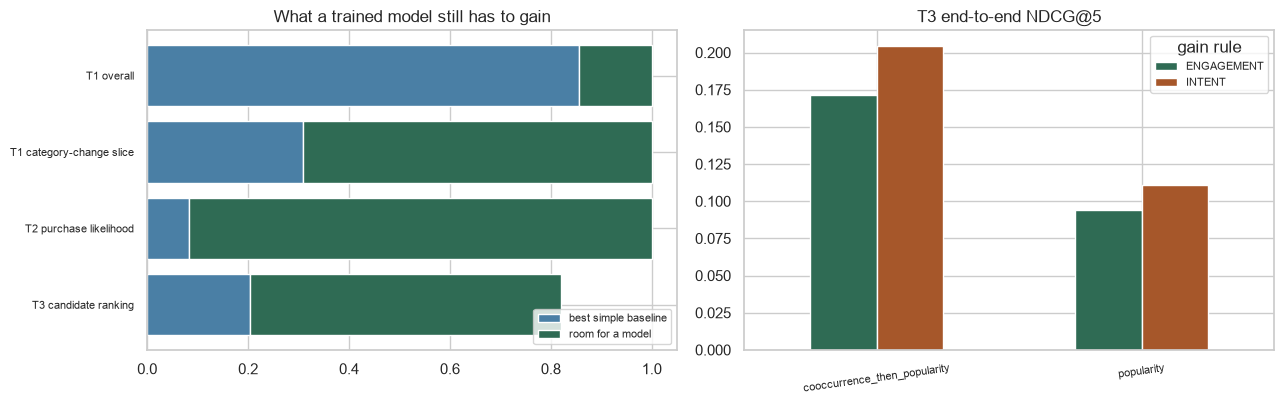

In [30]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.2))

position = np.arange(len(verdict))
axes[0].barh(position, verdict["best_simple"], color="#4A7FA5", label="best simple baseline")
axes[0].barh(position, verdict["room_for_a_model"], left=verdict["best_simple"],
             color="#2F6B54", label="room for a model")
axes[0].set_yticks(position)
axes[0].set_yticklabels(verdict["task"], fontsize=8)
axes[0].set_xlim(0, 1.05)
axes[0].invert_yaxis()
axes[0].set_title("What a trained model still has to gain")
axes[0].legend(fontsize=8, loc="lower right")

comparison.pivot(index="retrieval", columns="gain_rule", values="e2e_ndcg@5").plot(
    kind="bar", ax=axes[1], color=["#2F6B54", "#A6572A"])
axes[1].set_title("T3 end-to-end NDCG@5")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=8, labelsize=8)
axes[1].legend(title="gain rule", fontsize=8)

plt.tight_layout()
plt.show()

## Two averages and four client strata — ADR-001

`ADR-001` fixes how every comparison in this project is averaged, so this notebook has to publish
its baselines in that shape. Otherwise nothing downstream can be compared against them.

**Macro is the headline.** Each client counts once. `S1-DS-05/06` measures that the largest tenth
of clients hold about two thirds of the validation events, so a micro average is mostly a report
about those clients — while `R3` and `R4` produce a model per device and are read per device.

**Micro is always printed next to it.** It is the convention in the recommendation literature, and
publishing both is what stops anyone, us included, from picking the flattering one later.

**Clients are bucketed by TRAIN events**, because that is what a device would have to learn from.
A baseline that is flat across the buckets means the *task* does not favour heavy clients, so any
regime difference measured later is about the regime and not about who was in the bucket.

In [31]:
train_history = train.groupby("user").size()
STRATA_EDGES = [10, 20, 50, 100, np.inf]
STRATA_LABELS = ["10-19", "20-49", "50-99", "100+"]


def summarise(name, values, users):
    """Micro, macro, and macro inside each client-history bucket."""
    frame = pd.DataFrame({"value": np.asarray(values, dtype="float64"),
                          "client": np.asarray(users)})
    frame = frame.dropna(subset=["value"])
    frame["bucket"] = pd.cut(frame["client"].map(train_history).fillna(0),
                             bins=STRATA_EDGES, labels=STRATA_LABELS, right=False)

    per_client = frame.groupby("client", observed=True)["value"].mean()
    by_bucket = (frame.groupby(["bucket", "client"], observed=True)["value"].mean()
                 .groupby("bucket", observed=True).mean())

    row = {"metric": name, "micro": frame["value"].mean(), "macro": per_client.mean(),
           "clients": per_client.size}
    for label in STRATA_LABELS:
        row[label] = by_bucket.get(label, np.nan)
    return row


t1_users = val_steps["user"].to_numpy()
t3_users = queries.set_index("query_id").loc[
    per_query[(SELECTED_RETRIEVAL, SELECTED_GAIN)].index, "user"].to_numpy()

averaged = pd.DataFrame([
    summarise("T1 overall - repeat current category",
              np.where(same_category, 1.0, 0.0), t1_users),
    summarise("T1 overall - transition table MRR@20", transition_rr, t1_users),
    summarise("T1 slice - transition table MRR@20", slice_rr, changed["user"].to_numpy()),
    summarise("T3 - e2e NDCG@5",
              per_query[(SELECTED_RETRIEVAL, SELECTED_GAIN)]["ndcg"].to_numpy(), t3_users),
]).round(4)

print(averaged.to_string(index=False))

                              metric  micro  macro  clients  10-19  20-49  50-99   100+
T1 overall - repeat current category 0.8232 0.7879    31576 0.7940 0.7871 0.7890 0.7796
T1 overall - transition table MRR@20 0.8560 0.8258    31576 0.8335 0.8249 0.8253 0.8175
  T1 slice - transition table MRR@20 0.3085 0.3144    16096 0.3303 0.3111 0.3088 0.3129
                     T3 - e2e NDCG@5 0.2046 0.2707     4591 0.2929 0.2768 0.2643 0.2481


### Why `T2` gets a different treatment

`PR-AUC` is not a mean of per-decision values, so it does not decompose per client. Average
precision needs both classes present, and most clients have no purchase at all — for them it is
undefined, not zero. Averaging it per client would be inventing a number.

So `T2` keeps micro `PR-AUC` as its headline and adds a companion that **is** decomposable:
for each client, rank that client's own decisions by score, take the top three, and ask what
share of their real purchases were caught. A client with no purchase simply does not contribute.

In [32]:
best_t2 = t2_baselines.loc[t2_baselines["pr_auc"].idxmax(), "baseline"]
ranked_t2 = mature.assign(score=scores[best_t2])
ranked_t2["rank_for_client"] = ranked_t2.groupby("user")["score"].rank(
    ascending=False, method="first")
ranked_t2["caught"] = (ranked_t2["rank_for_client"] <= 3) & (ranked_t2["label"] == 1)

by_client = ranked_t2.groupby("user").agg(purchases=("label", "sum"),
                                          caught=("caught", "sum"))
buyers = by_client[by_client["purchases"] > 0]
recall_at_3 = buyers["caught"] / buyers["purchases"]

averaged = pd.concat([averaged, pd.DataFrame([
    summarise("T2 - purchases caught in the client's top 3",
              recall_at_3.to_numpy(), recall_at_3.index.to_numpy())
])], ignore_index=True).round(4)

print(averaged.to_string(index=False))
print()
print(f"T2 micro PR-AUC stays {t2_baselines['pr_auc'].max():.4f}. The companion above covers")
print(f"{len(buyers):,} clients who actually bought something; the other "
      f"{len(by_client) - len(buyers):,} have no purchase to catch.")

                                     metric  micro  macro  clients  10-19  20-49  50-99   100+
       T1 overall - repeat current category 0.8232 0.7879    31576 0.7940 0.7871 0.7890 0.7796
       T1 overall - transition table MRR@20 0.8560 0.8258    31576 0.8335 0.8249 0.8253 0.8175
         T1 slice - transition table MRR@20 0.3085 0.3144    16096 0.3303 0.3111 0.3088 0.3129
                            T3 - e2e NDCG@5 0.2046 0.2707     4591 0.2929 0.2768 0.2643 0.2481
T2 - purchases caught in the client's top 3 0.6021 0.6021     6387 0.7232 0.6518 0.5735 0.4047

T2 micro PR-AUC stays 0.0831. The companion above covers
6,387 clients who actually bought something; the other 29,343 have no purchase to catch.


## TaskExample artifacts

The last open gap, and the one every `S2` artifact lists as a blocker.

Until now each task rebuilt its own examples from the raw parquet. That is how this notebook and
the `S2` smoke test ended up with **263 different `T1` decisions** — caught only because an
assertion compared the counts. A frozen example file makes that class of divergence *impossible*
rather than merely detectable.

Each row carries the fields `S1-DS-05/06` specified: the client, the decision, the label, the
mask, the status, and when the label matures. Rows are written per task with the cohort and split
attached, so a downstream reader never has to re-derive membership.

These files contain pseudonymous user ids and are **internal**.

In [33]:
def write_examples(name, frame):
    path = OUTPUT_DIR / f"INTERNAL_DO_NOT_UPLOAD_task_examples_{name}_v1.proposed.parquet"
    frame.to_parquet(path, index=False)
    return {"task": name, "rows": len(frame), "clients": int(frame["client"].nunique()),
            "observed": int((frame["status"] == "OBSERVED").sum()),
            "censored": int((frame["status"] == "CENSORED").sum()),
            "file": path.name, "kb": round(path.stat().st_size / 1024, 1)}


COMMON = {"cohort": "C1", "split": "VALIDATION"}

# T1 - every decision is observed: the answer is inside the session that produced it.
t1_examples = pd.DataFrame({
    "client": val_steps["user"].to_numpy(),
    "session": val_steps["session"].to_numpy(),
    "decision_order": val_steps["order"].to_numpy(),
    "current_category": val_steps["category"].to_numpy(),
    "label_value": val_steps["next_category"].astype("float64").to_numpy(),
    "category_changed": (~same_category),
    "task_mask": True,
    "status": "OBSERVED",
    "label_matures_at": val_steps["event_time"].to_numpy(),
    **COMMON,
})

t2_examples = t2[["user", "session", "query_item", "query_category", "query_order",
                  "label_value", "task_mask", "status", "label_matures_at"]].rename(
    columns={"user": "client", "query_item": "item", "query_category": "category",
             "query_order": "decision_order"}).assign(**COMMON)

# T3 - one row per (query, eligible positive), carrying the gain under the selected rule.
t3_examples = positives.merge(
    queries[["query_id", "user", "session", "query_order", "query_category"]],
    on="query_id")[["user", "session", "query_id", "query_order", "query_category",
                    "query_item", "item", "event_type", f"gain_{SELECTED_GAIN}"]].rename(
    columns={"user": "client", "query_order": "decision_order",
             "query_category": "category", "item": "positive_item",
             f"gain_{SELECTED_GAIN}": "label_value"})
t3_examples["task_mask"] = True
t3_examples["status"] = "OBSERVED"
t3_examples["label_matures_at"] = t3_examples["session"].map(
    validation.groupby("session")["event_time"].max())
t3_examples = t3_examples.assign(**COMMON)

manifest = pd.DataFrame([write_examples(name, frame) for name, frame in
                         [("t1", t1_examples), ("t2", t2_examples), ("t3", t3_examples)]])
print(manifest.to_string(index=False))
print()
print("Downstream tasks read these instead of rebuilding decisions from the parquet.")
print("The 263-decision divergence between this notebook and the S2 smoke test could not")
print("have happened if these files had existed.")

task    rows  clients  observed  censored                                                        file     kb
  t1  438185    31576    438185         0 INTERNAL_DO_NOT_UPLOAD_task_examples_t1_v1.proposed.parquet 7084.0
  t2  392554    42312    322087     70467 INTERNAL_DO_NOT_UPLOAD_task_examples_t2_v1.proposed.parquet 6696.8
  t3 1096774    29330   1096774         0 INTERNAL_DO_NOT_UPLOAD_task_examples_t3_v1.proposed.parquet 9388.4

Downstream tasks read these instead of rebuilding decisions from the parquet.
The 263-decision divergence between this notebook and the S2 smoke test could not
have happened if these files had existed.


## TRAIN examples — the half that was missing

The task is called *Task Examples*, and the first version emitted only VALIDATION. A model
cannot train on validation data, so every `S2` task would have been blocked on arrival.

Reported bluntly because the checks did not catch it: all 25 of them asked whether what exists
is correct. None asked whether something that should exist is absent.

### How the duplication is avoided

Writing the construction twice — once for VALIDATION, once for TRAIN — is how the two silently
drift apart. Instead the logic becomes a function, and the function is **proved equivalent to
the already-verified VALIDATION path** before it is trusted on TRAIN:

> if `build_t2(validation)` reproduces the `t2` computed earlier, row for row, then the function
> is the same rule, and its output on TRAIN is the same rule applied to TRAIN.

An assertion enforces that. A comment claiming it would not.

In [34]:
def build_t2(frame):
    """First view of a product in a session, labelled by a later purchase of it."""
    views = frame.loc[frame["event_type"] == "view"]
    decisions = (views.drop_duplicates(subset=["session", "item"], keep="first")
                 [["session", "user", "item", "category", "order", "event_time"]]
                 .rename(columns={"order": "decision_order"})
                 .reset_index(drop=True))

    purchases = frame.loc[frame["event_type"] == "purchase", ["session", "item", "order"]]
    matched = decisions[["session", "item", "decision_order"]].merge(
        purchases, on=["session", "item"], how="left")
    # max, not first: a repeated purchase fans the merge out and the first row can precede
    # the view.
    matched["after"] = matched["order"] > matched["decision_order"]
    label = matched.groupby(["session", "item"])["after"].max().rename("label").reset_index()

    decisions = decisions.merge(label, on=["session", "item"], how="left")
    decisions["label"] = decisions["label"].fillna(False).astype("int8")

    # No observable horizon means censored, never negative.
    session_end = frame.groupby("session")["order"].max()
    decisions["censored"] = ((decisions["label"] == 0)
                             & (decisions["decision_order"] == decisions["session"].map(session_end)))
    decisions["task_mask"] = ~decisions["censored"]
    decisions["status"] = np.where(decisions["task_mask"], "OBSERVED", "CENSORED")
    decisions["label_value"] = decisions["label"].astype("float64").where(decisions["task_mask"])
    decisions["label_matures_at"] = decisions["session"].map(
        frame.groupby("session")["event_time"].max())
    return decisions


# Proof before trust: the function must reproduce the verified VALIDATION result exactly.
check_t2 = build_t2(validation)
assert len(check_t2) == len(t2), f"{len(check_t2):,} vs {len(t2):,} decisions"
assert int(check_t2["label"].sum()) == int(t2["label"].sum()), "label totals differ"
assert int(check_t2["censored"].sum()) == int(t2["censored"].sum()), "censoring differs"
print(f"build_t2 reproduces the verified VALIDATION result: {len(check_t2):,} decisions, "
      f"{int(check_t2['label'].sum()):,} positives, {int(check_t2['censored'].sum()):,} censored")
del check_t2

build_t2 reproduces the verified VALIDATION result: 392,554 decisions, 11,297 positives, 70,467 censored


In [35]:
def build_t3_positives(frame):
    """Eligible later engagements for each first-view query, with their gains."""
    views = frame.loc[frame["event_type"] == "view"]
    q = (views.drop_duplicates(subset=["session", "item"], keep="first")
         [["session", "user", "item", "category", "order", "event_time"]]
         .rename(columns={"item": "query_item", "category": "query_category",
                          "order": "query_order", "event_time": "query_time"})
         .reset_index(drop=True))
    q["query_id"] = np.arange(len(q), dtype="int64")
    q["query_band"] = q["query_item"].map(catalog["price_band"]).fillna(-1).astype("int8")
    # The catalogue is fitted on all of TRAIN. For VALIDATION queries that is strictly the
    # past. For TRAIN queries it is not: popularity includes events after the query. That is
    # in-sample for training data - acceptable, because the model is allowed to see its own
    # training split - but it is NOT acceptable for evaluation, and evaluation never uses it.

    later = q[["query_id", "session", "query_item", "query_category", "query_band",
               "query_order"]].merge(
        frame[["session", "item", "event_type", "order"]], on="session", how="inner")
    later = later.loc[later["order"] > later["query_order"]]

    keep = eligible(later["item"].to_numpy(), later["query_item"].to_numpy(),
                    later["query_category"].to_numpy(), later["query_band"].to_numpy())
    later = later.loc[keep]

    strongest = (later.assign(strength=later["event_type"].map(STRENGTH))
                 .sort_values("strength")
                 .drop_duplicates(subset=["query_id", "item"], keep="last")
                 [["query_id", "query_item", "item", "event_type"]])
    for name, rule in GAIN_RULES.items():
        strongest[f"gain_{name}"] = strongest["event_type"].map(rule).astype("int8")
    return q, strongest


check_q, check_p = build_t3_positives(validation)
assert len(check_q) == len(queries), f"{len(check_q):,} vs {len(queries):,} queries"
assert len(check_p) == len(positives), f"{len(check_p):,} vs {len(positives):,} positives"
print(f"build_t3_positives reproduces VALIDATION: {len(check_q):,} queries, "
      f"{len(check_p):,} positives")
del check_q, check_p

build_t3_positives reproduces VALIDATION: 392,554 queries, 1,096,774 positives


In [36]:
def as_examples(frame, split, **columns):
    return frame.assign(cohort="C1", split=split, **columns)


# --- T1 -----------------------------------------------------------------------------------
train_t1 = as_examples(pd.DataFrame({
    "client": train_steps["user"].to_numpy(),
    "session": train_steps["session"].to_numpy(),
    "decision_order": train_steps["order"].to_numpy(),
    "current_category": train_steps["category"].to_numpy(),
    "label_value": train_steps["next_category"].astype("float64").to_numpy(),
    "category_changed": (train_steps["category"] != train_steps["next_category"]).to_numpy(),
    "task_mask": True,
    "status": "OBSERVED",
    "label_matures_at": train_steps["event_time"].to_numpy(),
}), "TRAIN")

# --- T2 -----------------------------------------------------------------------------------
train_t2 = as_examples(build_t2(train).rename(columns={"user": "client"})[
    ["client", "session", "item", "category", "decision_order", "label_value",
     "task_mask", "status", "label_matures_at"]], "TRAIN")

# --- T3 -----------------------------------------------------------------------------------
train_queries, train_positives = build_t3_positives(train)
train_t3 = as_examples(train_positives.merge(
    train_queries[["query_id", "user", "session", "query_order", "query_category"]],
    on="query_id").rename(columns={
        "user": "client", "query_order": "decision_order", "query_category": "category",
        "item": "positive_item", f"gain_{SELECTED_GAIN}": "label_value"})[
    ["client", "session", "query_id", "decision_order", "category", "query_item",
     "positive_item", "event_type", "label_value"]],
    "TRAIN", task_mask=True, status="OBSERVED")
train_t3["label_matures_at"] = train_t3["session"].map(
    train.groupby("session")["event_time"].max())

written = pd.DataFrame([
    write_examples(f"{name}_train", frame)
    for name, frame in [("t1", train_t1), ("t2", train_t2), ("t3", train_t3)]
])
print(written.to_string(index=False))
print()
print(f"TRAIN examples now exist for all three tasks. A model has something to learn from,")
print(f"which was not true an hour ago.")

    task    rows  clients  observed  censored                                                              file      kb
t1_train 3113814    95990   3113814         0 INTERNAL_DO_NOT_UPLOAD_task_examples_t1_train_v1.proposed.parquet 49046.1
t2_train 2770471    97279   2291753    478718 INTERNAL_DO_NOT_UPLOAD_task_examples_t2_train_v1.proposed.parquet 44419.6
t3_train 8088359    95236   8088359         0 INTERNAL_DO_NOT_UPLOAD_task_examples_t3_train_v1.proposed.parquet 79389.5

TRAIN examples now exist for all three tasks. A model has something to learn from,
which was not true an hour ago.


## Why there are no TEST examples here

A decision, not an omission.

**The construction rules are not frozen yet.** `S1-DS-09` still owns one open question — whether
the price band stays a hard filter on `T3` candidates. The measurement in this notebook says
relaxing it widens the evaluable universe from `37.9%` to `56.6%`. If it is relaxed, every `T3`
candidate list changes, and TEST examples built today would be discarded tomorrow.

**The strongest guarantee in this pipeline is `test_rows_read = 0`.** It is a headline check in
this notebook and in the `S2` smoke test. Spending it before the freeze buys nothing, because no
model trains on TEST.

**So TEST examples belong to `S1-DS-09`**, built in one pass after the rules are frozen, and
sealed. That is a scheduling decision with a reason, and it is recorded here so the next reader
does not mistake it for something forgotten.

In [37]:
artifacts = sorted(OUTPUT_DIR.glob("*"))
inventory = pd.DataFrame([
    {"file": path.name, "MB": round(path.stat().st_size / 1024 / 1024, 2),
     "internal": path.name.startswith("INTERNAL")}
    for path in artifacts
])
print(inventory.to_string(index=False))
print()
print(f"{int(inventory['internal'].sum())} internal files carry pseudonymous user ids and")
print("must not be uploaded. The rest are safe to share.")
print()
print("Splits covered by task examples:")
for name, frame in [("T1", (t1_examples, train_t1)), ("T2", (t2_examples, train_t2)),
                    ("T3", (t3_examples, train_t3))]:
    validation_rows, train_rows = len(frame[0]), len(frame[1])
    print(f"  {name}  TRAIN {train_rows:>9,}   VALIDATION {validation_rows:>9,}   "
          f"TEST  owned by S1-DS-09")

                                                             file    MB  internal
INTERNAL_DO_NOT_UPLOAD_task_examples_t1_train_v1.proposed.parquet 47.90      True
      INTERNAL_DO_NOT_UPLOAD_task_examples_t1_v1.proposed.parquet  6.92      True
INTERNAL_DO_NOT_UPLOAD_task_examples_t2_train_v1.proposed.parquet 43.38      True
      INTERNAL_DO_NOT_UPLOAD_task_examples_t2_v1.proposed.parquet  6.54      True
INTERNAL_DO_NOT_UPLOAD_task_examples_t3_train_v1.proposed.parquet 77.53      True
      INTERNAL_DO_NOT_UPLOAD_task_examples_t3_v1.proposed.parquet  9.17      True
                                 item_catalog_v1.proposed.parquet  2.11     False
                                 price_transform_v1.proposed.json  0.00     False
                           t3_candidate_lists_v1.proposed.parquet  8.97     False
                                     t3_protocol_v1.proposed.json  0.00     False
                                   task_headroom_v1.proposed.json  0.01     False
                

## 11. Can these tasks separate the regimes?

Headroom is necessary but not sufficient. A task is only usable for this project if the
difference between `R1` and `R4` is **larger than the noise in the measurement**. A task with
plenty of room but too few evaluable examples will report differences that are indistinguishable
from resampling error, and the comparison will say nothing.

Each headline metric is the mean of a per-decision score, so its standard error is
`std / sqrt(n)` and the 95% interval is `±1.96 × SE`. `PR-AUC` is not a mean, so it is
bootstrapped instead.

Two regimes evaluated on the *same* decisions give a paired comparison, whose interval is
narrower than the ones below. These are therefore a **conservative** bound on resolution.

In [38]:
def half_width(values):
    values = np.asarray(values, dtype=float)
    return float(1.96 * values.std(ddof=1) / np.sqrt(len(values)))


def bootstrap_half_width(labels, scores, draws=200, seed=11):
    """PR-AUC is not a mean, so its interval has to be resampled."""
    generator = np.random.default_rng(seed)
    labels, scores = np.asarray(labels), np.asarray(scores)
    drawn = [average_precision_score(labels[index], scores[index])
             for index in (generator.integers(0, len(labels), len(labels))
                           for _ in range(draws))]
    return float(1.96 * np.std(drawn, ddof=1))


t3_scores = per_query[(SELECTED_RETRIEVAL, SELECTED_GAIN)]["ndcg"]
best_t2 = t2_baselines.loc[t2_baselines["pr_auc"].idxmax(), "baseline"]

resolution = pd.DataFrame([
    {"task": "T1 overall", "metric": "MRR@20", "n": len(val_steps),
     "value": float(t1_baselines["mrr@20"].max()), "half_width": half_width(transition_rr)},
    {"task": "T1 category-change slice", "metric": "MRR@20", "n": len(changed),
     "value": float(slice_baselines["mrr@20"].max()), "half_width": half_width(slice_rr)},
    {"task": "T2 purchase likelihood", "metric": "PR-AUC", "n": len(mature),
     "value": float(t2_baselines["pr_auc"].max()),
     "half_width": bootstrap_half_width(mature["label"].to_numpy(), scores[best_t2])},
    {"task": "T3 candidate ranking", "metric": "e2e NDCG@5", "n": len(t3_scores),
     "value": float(headline["e2e_ndcg@5"]), "half_width": half_width(t3_scores)},
])
resolution = resolution.merge(verdict[["task", "room_for_a_model"]], on="task")
resolution["room_in_half_widths"] = (resolution["room_for_a_model"]
                                     / resolution["half_width"]).round(0)
resolution["half_width"] = resolution["half_width"].round(4)
resolution = resolution.round(4)

print(resolution.to_string(index=False))
print()
print("room_in_half_widths is the question the project actually rests on: how many resolvable")
print("steps separate a model-free rule from a perfect one. A task with only a handful of them")
print("cannot rank R1..R5 no matter how much room it appears to have.")
print()
print("Scaling note: these run on a quarter of C1. The full cohort has four times the")
print(f"decisions, so each interval narrows by a factor of about {np.sqrt(MODULO):.0f}.")

                    task     metric      n  value  half_width  room_for_a_model  room_in_half_widths
              T1 overall     MRR@20 438185 0.8560      0.0009            0.1440                152.0
T1 category-change slice     MRR@20  77457 0.3085      0.0026            0.6915                269.0
  T2 purchase likelihood     PR-AUC 322087 0.0831      0.0029            0.9169                315.0
    T3 candidate ranking e2e NDCG@5  18814 0.2046      0.0048            0.6155                128.0

room_in_half_widths is the question the project actually rests on: how many resolvable
steps separate a model-free rule from a perfect one. A task with only a handful of them
cannot rank R1..R5 no matter how much room it appears to have.

Scaling note: these run on a quarter of C1. The full cohort has four times the
decisions, so each interval narrows by a factor of about 2.


## 12. Artifacts

`t3_protocol_v1.proposed.json` is what `S1-DS-09` will freeze: the decisions sit next to the
numbers that chose them, so a reader can re-derive them instead of trusting them.
`task_headroom_v1.proposed.json` is the evidence that the project is worth continuing at all.

Both are `PROPOSED`. Nothing is frozen until `S1-DS-09`.

In [39]:
scope = {
    "cohort": "C1",
    "cohort_users": int(len(C1_ALL)),
    "measured_users": int(len(C1_USERS)),
    "user_slice": f"user_id % {MODULO} == {RESIDUE}",
    "slice_reason": "C1 holds 17.6M TRAIN events, beyond available memory; whole users kept",
    "measured_on": "VALIDATION",
    "test_rows_read": 0,
    "excluded_sessions_consumed": int(len(excluded_sessions)),
    "train_events": int(len(train)),
    "validation_events": int(len(validation)),
    "validation_sessions": int(validation["session"].nunique()),
}

t3_protocol = {
    "status": "PROPOSED",
    "scope": scope,
    "gain_rule": {
        "selected": SELECTED_GAIN,
        "gains": GAIN_RULES[SELECTED_GAIN],
        "basis": "the plan's documented proposal, kept because the measurement shows it is "
                 "not saturated",
        "sensitivity_analysis": sensitivity["gain_rule"],
    },
    "retrieval": {
        "selected": SELECTED_RETRIEVAL,
        "basis": "higher end-to-end NDCG@5 under the selected gain rule",
        "popularity_half_life_days": config["t3_protocol"]["popularity_half_life_days"],
        "max_candidates": int(CAP),
    },
    "eligibility": {
        "rule": ("different item, same category, present in the TRAIN catalogue"
                 + (", same TRAIN median-price band" if REQUIRE_SAME_BAND else "")),
        "price_band_required": bool(REQUIRE_SAME_BAND),
        "applied_to": ["candidate construction", "positive counting"],
        "engagements_outside_the_eligible_universe": round(ineligible_share, 4),
    },
    "metrics": {
        "headline": "end-to-end NDCG@5",
        "secondary": ["MRR", "HR@3", "Candidate Recall@100"],
        "retrieval_miss": "scores zero",
        "positive_injection": False,
        "ceiling": "graded NDCG of a perfect reranking of what was retrieved",
        "conditional_metrics": "diagnostic only",
    },
    "measurement": comparison.to_dict(orient="records"),
    "price_transform": price_transform,
    "price_band_experiment": band_comparison.to_dict(orient="records"),
    "price_band_status": "MEASURED HERE, DECIDED IN S1-DS-09",
    "gain_drift": {
        "event_mix_by_split": drift.reset_index(names="event_type").to_dict(orient="records"),
        "daily_cart_share_percent": cart_spread.reset_index().to_dict(orient="records"),
        "largest_relative_drift_percent": round(float(drift["relative_%"].abs().max()), 2),
        "test_split": "not readable here; S1-DS-09 must re-check",
    },
}

headroom = {
    "status": "PROPOSED",
    "scope": scope,
    "verdict": verdict.to_dict(orient="records"),
    "resolution": resolution.to_dict(orient="records"),
    "t1": {
        "target": "category of the first later event on a different item in the session",
        "headline_metric": "MRR - unchanged from the plan",
        "decisions": int(len(val_steps)),
        "same_category_share": round(float(same_category.mean()), 4),
        "baselines": t1_baselines.to_dict(orient="records"),
        "category_change_slice": {
            "status": "RECOMMENDED_NEEDS_ADR",
            "decisions": int(len(changed)),
            "baselines": slice_baselines.to_dict(orient="records"),
        },
    },
    "t2": {
        "decision": "first view of a product in a session",
        "label": "the same product purchased later in the session, canonical order",
        "censoring": "a decision with no observable horizon is censored, never negative",
        "decisions": int(len(t2)),
        "censored": int(t2["censored"].sum()),
        "mature": int(len(mature)),
        "positives": int(mature["label"].sum()),
        "base_rate": round(base_rate, 4),
        "baselines": t2_baselines.to_dict(orient="records"),
    },
    "t3": {
        "queries": int(len(queries)),
        "evaluable_queries": int(headline["evaluable_queries"]),
        "e2e_ndcg@5": float(headline["e2e_ndcg@5"]),
        "reranker_ceiling": float(headline["reranker_ceiling"]),
        "recall@100": float(headline["recall@100"]),
    },
    "adr_001": {
        "headline_average": "macro - one vote per client",
        "reported_alongside": "micro - one vote per decision",
        "client_strata": STRATA_LABELS,
        "strata_basis": "TRAIN events per client, what a device would learn from",
        "averaged_baselines": averaged.to_dict(orient="records"),
        "t2_exception": "PR-AUC does not decompose per client; a top-3 companion is reported",
    },
    "task_examples": pd.concat([manifest, written], ignore_index=True).to_dict(
        orient="records"),
    "splits_emitted": {"TRAIN": True, "VALIDATION": True,
                       "TEST": "owned by S1-DS-09, after the freeze"},
    "shared_artifacts": {
        "vocabulary": "vocabulary_v1.proposed.json",
        "item_catalog": "item_catalog_v1.proposed.parquet",
        "candidate_lists": "t3_candidate_lists_v1.proposed.parquet",
        "price_transform": "price_transform_v1.proposed.json",
        "why": "a task example's label is a code; without the vocabulary it has no meaning",
    },
    "corrections_from_review": [
        "positives and candidates share one eligibility function, verified in-notebook",
        "the excluded-session list is consumed, so TEST is never read",
        "every measurement is restricted to the C1 cohort",
        "sessions are assembled whole before any sequence logic",
        "ordering uses (event_time, source_row_number)",
        "null sessions become provenance singletons",
        "overall MRR remains the T1 headline; the slice is a recommendation needing an ADR",
        "room is reported as a difference and the T3 ceiling is a graded NDCG",
    ],
}

for name, payload in [("t3_protocol_v1.proposed.json", t3_protocol),
                      ("task_headroom_v1.proposed.json", headroom)]:
    path = OUTPUT_DIR / name
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"{path.name:36} {path.stat().st_size / 1024:6.1f} KB")

t3_protocol_v1.proposed.json            5.1 KB
task_headroom_v1.proposed.json          8.5 KB


## 13. Validation

Every claim this notebook hands downstream, checked against the objects it actually produced.
A check that reads a variable rather than a number typed into a cell is the only kind that can
still fail when the notebook is re-run.

In [40]:
positive_query = queries.set_index("query_id").loc[positives["query_id"]]
T3_FRACTIONS = ["recall@100", "e2e_ndcg@5", "reranker_ceiling", "e2e_mrr", "e2e_hr@3"]

# Time must not go backwards inside a session once the canonical order is applied.
same_session = (validation["session"].to_numpy()[1:] == validation["session"].to_numpy()[:-1])
forward = (validation["event_time"].to_numpy()[1:] >= validation["event_time"].to_numpy()[:-1])

# What the discarded rule would have produced: only the immediately following row counted.
next_item = validation.groupby("session")["item"].shift(-1)
naive_decisions = int((next_item.notna() & (next_item != validation["item"])).sum())

checks = [
    ("TEST is never read",
     validation["event_time"].max() < SPLITS["TEST"][0]),
    ("TRAIN stays inside its own interval",
     train["event_time"].min() >= TRAIN_START and train["event_time"].max() < TRAIN_END),
    ("every measured user belongs to C1",
     set(train["user"]) <= set(C1_ALL) and set(validation["user"]) <= set(C1_ALL)),
    ("no boundary-crossing session survives",
     not ((set(train["session"]) | set(validation["session"])) & excluded_sessions)),
    ("session keys match the frozen 64-bit rule",
     train["session"].dtype == np.uint64 and validation["session"].dtype == np.uint64),
    ("time never goes backwards inside a session",
     bool((forward | ~same_session).all())),
    ("category codes are dense and survived every shift",
     int(train["category"].max()) == len(categories) - 1),
    ("every query is the first view of its product in its session",
     not queries.duplicated(subset=["session", "query_item"]).any()),
    ("no positive lies outside the eligible universe",
     bool(eligible(positives["item"].to_numpy(), positives["query_item"].to_numpy(),
                   positive_query["query_category"].to_numpy(),
                   positive_query["query_band"].to_numpy()).all())),
    ("no candidate list exceeds the cap",
     int(pop_lists["rank"].max()) < CAP and int(cooc_lists["rank"].max()) < CAP),
    ("achieved NDCG never exceeds its own ceiling",
     bool((comparison["e2e_ndcg@5"] <= comparison["reranker_ceiling"] + 1e-9).all())),
    ("every reported T3 metric is a proper fraction",
     bool((comparison[T3_FRACTIONS] >= 0).all().all()
          and (comparison[T3_FRACTIONS] <= 1).all().all())),
    ("T2 censored decisions are excluded from the base rate",
     len(mature) == len(t2) - int(t2["censored"].sum())),
    ("T2 has no positive among the censored",
     int(t2.loc[t2["censored"], "label"].sum()) == 0),
    ("T1 skips repeated views instead of dropping them",
     len(val_steps) >= naive_decisions),
    ("the category vocabulary is persisted, so a label code has a meaning",
     (OUTPUT_DIR / "vocabulary_v1.proposed.json").exists()
     and len(vocabulary["categories"]["code_of_category_id"]) == len(categories)),
    ("the item catalogue is persisted, so the candidate universe is reproducible",
     (OUTPUT_DIR / "item_catalog_v1.proposed.parquet").exists()
     and len(catalog_out) == len(catalog)),
    ("candidate lists are persisted, not only their metrics",
     (OUTPUT_DIR / "t3_candidate_lists_v1.proposed.parquet").exists()),
    ("TRAIN examples exist for all three tasks",
     all(len(frame) > 0 for frame in (train_t1, train_t2, train_t3))),
    ("TRAIN examples outnumber VALIDATION ones, as the split sizes require",
     len(train_t1) > len(t1_examples) and len(train_t2) > len(t2_examples)),
    ("no TRAIN example leaked into a VALIDATION file or the reverse",
     set(train_t1["split"]) == {"TRAIN"} and set(t1_examples["split"]) == {"VALIDATION"}),
    ("TEST is emitted by nobody here, deliberately",
     not any("test" in path.name.lower() and "examples" in path.name.lower()
             for path in OUTPUT_DIR.glob("*"))),
    ("the fitted price bands are persisted, not left in memory",
     (OUTPUT_DIR / "price_transform_v1.proposed.json").exists()
     and len(price_transform["log_edges"]) == 3),
    ("censoring uses the representation the protocol specified",
     bool(t2.loc[~t2["task_mask"], "label_value"].isna().all())
     and bool(t2.loc[t2["task_mask"], "label_value"].notna().all())
     and set(t2["status"]) <= {"OBSERVED", "CENSORED"}),
    ("no censored decision reaches a task example as a negative",
     int(t2_examples.loc[t2_examples["status"] == "CENSORED", "label_value"]
         .notna().sum()) == 0),
    ("every task example file carries its client, mask and status",
     all({"client", "task_mask", "status", "label_matures_at"}.issubset(frame.columns)
         for frame in (t1_examples, t2_examples, t3_examples))),
    ("T1 examples match the decisions this notebook measured",
     len(t1_examples) == len(val_steps)),
    ("T2 examples match the decisions this notebook measured",
     len(t2_examples) == len(t2)),
    ("macro and micro are both published for every averaged metric",
     bool(averaged[["micro", "macro"]].notna().all().all())),
    ("every client stratum is populated",
     bool(averaged[STRATA_LABELS].notna().any().all())),
    ("gain drift is measured on both readable splits",
     set(drift.columns) >= {"TRAIN", "VALIDATION"}),
    ("the price band is measured under both rules, not assumed",
     len(band_comparison) == 2
     and bool(band_comparison["resolvable_steps"].notna().all())),
    ("the re-run path for the rule in use reproduces the published T3 number",
     abs(float(band_comparison.loc[band_comparison["eligibility"] == in_use,
                                   "e2e_ndcg@5"].iloc[0])
         - float(headline["e2e_ndcg@5"])) < 5e-3),
    ("the retrieval decision is read from the measurement, not hard-coded",
     SELECTED_RETRIEVAL == under_gain.loc[under_gain["e2e_ndcg@5"].idxmax(), "retrieval"]),
]

report = pd.DataFrame(checks, columns=["check", "passed"])
report["passed"] = report["passed"].astype(bool)
print(report.to_string(index=False))
print()
print(f"{int(report['passed'].sum())} of {len(report)} checks passed")
assert report["passed"].all(), report.loc[~report["passed"], "check"].tolist()

                                                                     check  passed
                                                        TEST is never read    True
                                       TRAIN stays inside its own interval    True
                                         every measured user belongs to C1    True
                                     no boundary-crossing session survives    True
                                 session keys match the frozen 64-bit rule    True
                                time never goes backwards inside a session    True
                         category codes are dense and survived every shift    True
               every query is the first view of its product in its session    True
                            no positive lies outside the eligible universe    True
                                         no candidate list exceeds the cap    True
                               achieved NDCG never exceeds its own ceiling    True
    